In [1]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Create folders for outputs
OUTPUT_DIR = Path("week2_outputs")
PLOT_DIR = OUTPUT_DIR / "plots"
REPORT_DIR = OUTPUT_DIR / "reports"

OUTPUT_DIR.mkdir(exist_ok=True)
PLOT_DIR.mkdir(exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)

print("Output folders created:")
print(OUTPUT_DIR)
print(PLOT_DIR)
print(REPORT_DIR)

Output folders created:
week2_outputs
week2_outputs\plots
week2_outputs\reports


In [7]:
FILE_PATH = "your_week1_dataset.csv"

df = pd.read_csv("data.csv", sep=";")

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully.
Rows: 4424
Columns: 37


In [8]:
df_original = df.copy()

print("Original dataset backup created.")

Original dataset backup created.


In [9]:
print("First 5 rows:")
display(df.head())

First 5 rows:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [10]:
print("Last 5 rows:")
display(df.tail())

Last 5 rows:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate
4423,1,10,1,9773,1,1,152.0,22,38,37,...,0,6,6,6,13.000000,0,12.7,3.7,-1.70,Graduate


In [11]:
print("Random sample:")
display(df.sample(min(5, len(df)), random_state=42))

Random sample:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
1255,4,39,1,9130,1,1,133.1,1,3,1,...,0,6,16,1,10.000000,0,11.1,0.6,2.02,Dropout
3458,1,17,1,9238,1,1,125.0,1,4,3,...,0,6,8,6,12.142857,0,16.2,0.3,-0.92,Graduate
3390,1,17,1,9853,1,1,133.0,1,38,38,...,0,7,7,7,12.285714,0,16.2,0.3,-0.92,Graduate
1497,1,17,2,9670,1,1,110.0,1,1,1,...,0,6,8,5,13.000000,0,15.5,2.8,-4.06,Graduate
1536,1,39,1,9500,1,1,130.0,1,37,19,...,0,7,14,0,0.000000,0,11.1,0.6,2.02,Dropout


In [12]:
rows, columns = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)
print("Dataset dimensions:", df.shape)

Number of rows: 4424
Number of columns: 37
Dataset dimensions: (4424, 37)


In [13]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualificati

In [14]:
print("Numerical Summary:")
display(df.describe())

Numerical Summary:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [15]:
print("Complete Statistical Summary:")
display(df.describe(include="all").T)

Complete Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Marital status,4424.0,NaN,NaN,NaN,1.178571,0.605747,1.0,1.0,1.0,1.0,6.0
Application mode,4424.0,NaN,NaN,NaN,18.669078,17.484682,1.0,1.0,17.0,39.0,57.0
Application order,4424.0,NaN,NaN,NaN,1.727848,1.313793,0.0,1.0,1.0,2.0,9.0
Course,4424.0,NaN,NaN,NaN,8856.642631,2063.566416,33.0,9085.0,9238.0,9556.0,9991.0
Daytime/evening attendance\t,4424.0,NaN,NaN,NaN,0.890823,0.311897,0.0,1.0,1.0,1.0,1.0
Previous qualification,4424.0,NaN,NaN,NaN,4.577758,10.216592,1.0,1.0,1.0,1.0,43.0
Previous qualification (grade),4424.0,NaN,NaN,NaN,132.613314,13.188332,95.0,125.0,133.1,140.0,190.0
Nacionality,4424.0,NaN,NaN,NaN,1.873192,6.914514,1.0,1.0,1.0,1.0,109.0
Mother's qualification,4424.0,NaN,NaN,NaN,19.561935,15.603186,1.0,2.0,19.0,37.0,44.0
Father's qualification,4424.0,NaN,NaN,NaN,22.275316,15.343108,1.0,3.0,19.0,37.0,44.0


In [16]:
dtype_report = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Non_Null_Count": df.notna().sum().values,
    "Missing_Count": df.isna().sum().values
})

display(dtype_report)

,Column,Data_Type,Non_Null_Count,Missing_Count
0,Marital status,int64,4424,0
1,Application mode,int64,4424,0
2,Application order,int64,4424,0
3,Course,int64,4424,0
4,Daytime/evening attendance\t,int64,4424,0
5,Previous qualification,int64,4424,0
6,Previous qualification (grade),float64,4424,0
7,Nacionality,int64,4424,0
8,Mother's qualification,int64,4424,0
9,Father's qualification,int64,4424,0


In [17]:
dtype_report.to_csv(
    REPORT_DIR / "data_type_report.csv",
    index=False
)

In [18]:
old_columns = df.columns.tolist()

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-zA-Z0-9]+", "_", regex=True)
    .str.strip("_")
)

column_changes = pd.DataFrame({
    "Original_Name": old_columns,
    "Cleaned_Name": df.columns
})

display(column_changes)

,Original_Name,Cleaned_Name
0,Marital status,marital_status
1,Application mode,application_mode
2,Application order,application_order
3,Course,course
4,Daytime/evening attendance\t,daytime_evening_attendance
5,Previous qualification,previous_qualification
6,Previous qualification (grade),previous_qualification_grade
7,Nacionality,nacionality
8,Mother's qualification,mother_s_qualification
9,Father's qualification,father_s_qualification


In [19]:

column_changes.to_csv(
    REPORT_DIR / "column_name_changes.csv",
    index=False
)

In [20]:
duplicate_columns = df.columns[df.columns.duplicated()].tolist()

if duplicate_columns:
    print("Duplicate column names found:")
    print(duplicate_columns)
else:
    print("No duplicate column names found.")

No duplicate column names found.


In [21]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)
print(
    "Duplicate percentage:",
    round((duplicate_count / len(df)) * 100, 2),
    "%"
)

Number of duplicate rows: 0
Duplicate percentage: 0.0 %


In [22]:
duplicates = df[df.duplicated(keep=False)]

if len(duplicates) > 0:
    display(duplicates.sort_values(by=list(df.columns)))
else:
    print("No duplicate records found.")

No duplicate records found.


In [23]:
duplicates.to_csv(
    REPORT_DIR / "duplicate_records.csv",
    index=False
)

In [24]:
rows_before_duplicates = len(df)

df = df.drop_duplicates()

rows_after_duplicates = len(df)

duplicates_removed = rows_before_duplicates - rows_after_duplicates

print("Rows before duplicate removal:", rows_before_duplicates)
print("Rows after duplicate removal:", rows_after_duplicates)
print("Duplicate rows removed:", duplicates_removed)

Rows before duplicate removal: 4424
Rows after duplicate removal: 4424
Duplicate rows removed: 0


In [25]:
missing_report = pd.DataFrame({
    "Column": df.columns,
    "Missing_Count": df.isnull().sum(),
    "Total_Rows": len(df),
})

missing_report["Missing_Percentage"] = (
    missing_report["Missing_Count"] /
    missing_report["Total_Rows"] * 100
)

missing_report = missing_report.sort_values(
    "Missing_Percentage",
    ascending=False
)

display(missing_report)

,Column,Missing_Count,Total_Rows,Missing_Percentage
marital_status,marital_status,0,4424,0.0
application_mode,application_mode,0,4424,0.0
application_order,application_order,0,4424,0.0
course,course,0,4424,0.0
daytime_evening_attendance,daytime_evening_attendance,0,4424,0.0
previous_qualification,previous_qualification,0,4424,0.0
previous_qualification_grade,previous_qualification_grade,0,4424,0.0
nacionality,nacionality,0,4424,0.0
mother_s_qualification,mother_s_qualification,0,4424,0.0
father_s_qualification,father_s_qualification,0,4424,0.0


In [26]:
missing_report.to_csv(
    REPORT_DIR / "missing_value_report_before.csv",
    index=False
)

In [27]:
total_missing = df.isnull().sum().sum()

print("Total missing values:", total_missing)

if total_missing == 0:
    print("No missing values were found.")
else:
    print("Missing values require treatment.")

Total missing values: 0
No missing values were found.


In [28]:
missing_plot = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_plot = missing_plot[missing_plot > 0]

if len(missing_plot) > 0:

    plt.figure(figsize=(12, 6))

    sns.barplot(
        x=missing_plot.index,
        y=missing_plot.values
    )

    plt.title("Missing Values by Column")
    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.savefig(
        PLOT_DIR / "missing_values_barplot.png",
        dpi=300
    )

    plt.show()

else:
    print("No missing values to visualize.")

No missing values to visualize.


In [29]:
if df.isnull().sum().sum() > 0:

    plt.figure(figsize=(12, 7))

    sns.heatmap(
        df.isnull(),
        cbar=False,
        yticklabels=False
    )

    plt.title("Missing Value Pattern")
    plt.tight_layout()

    plt.savefig(
        PLOT_DIR / "missing_value_heatmap.png",
        dpi=300
    )

    plt.show()

In [30]:
HIGH_MISSING_THRESHOLD = 50

high_missing_columns = missing_report[
    missing_report["Missing_Percentage"] >= HIGH_MISSING_THRESHOLD
]

print("Columns with >= 50% missing values:")

if len(high_missing_columns) > 0:
    display(high_missing_columns)
else:
    print("None found.")

Columns with >= 50% missing values:
None found.


In [31]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['marital_status', 'application_mode', 'application_order', 'course', 'daytime_evening_attendance', 'previous_qualification', 'previous_qualification_grade', 'nacionality', 'mother_s_qualification', 'father_s_qualification', 'mother_s_occupation', 'father_s_occupation', 'admission_grade', 'displaced', 'educational_special_needs', 'debtor', 'tuition_fees_up_to_date', 'gender', 'scholarship_holder', 'age_at_enrollment', 'international', 'curricular_units_1st_sem_credited', 'curricular_units_1st_sem_enrolled', 'curricular_units_1st_sem_evaluations', 'curricular_units_1st_sem_approved', 'curricular_units_1st_sem_grade', 'curricular_units_1st_sem_without_evaluations', 'curricular_units_2nd_sem_credited', 'curricular_units_2nd_sem_enrolled', 'curricular_units_2nd_sem_evaluations', 'curricular_units_2nd_sem_approved', 'curricular_units_2nd_sem_grade', 'curricular_units_2nd_sem_without_evaluations', 'unemployment_rate', 'inflation_rate', 'gdp']

Categorical columns:
['target

In [32]:
for col in categorical_columns:
    df[col] = (
        df[col]
        .astype("string")
        .str.strip()
        .replace(r"\s+", " ", regex=True)
    )

print("Whitespace cleaned from categorical columns.")

Whitespace cleaned from categorical columns.


In [33]:
missing_tokens = [
    "",
    " ",
    "NA",
    "N/A",
    "na",
    "n/a",
    "NULL",
    "null",
    "None",
    "none",
    "-"
]

for col in categorical_columns:
    df[col] = df[col].replace(
        missing_tokens,
        np.nan
    )

print("Common missing-value tokens converted to NaN.")

Common missing-value tokens converted to NaN.


In [34]:
display(
    df.isnull().sum()
    .sort_values(ascending=False)
)

marital_status                                  0
application_mode                                0
application_order                               0
course                                          0
daytime_evening_attendance                      0
previous_qualification                          0
previous_qualification_grade                    0
nacionality                                     0
mother_s_qualification                          0
father_s_qualification                          0
mother_s_occupation                             0
father_s_occupation                             0
admission_grade                                 0
displaced                                       0
educational_special_needs                       0
debtor                                          0
tuition_fees_up_to_date                         0
gender                                          0
scholarship_holder                              0
age_at_enrollment                               0


In [35]:
potential_numeric_columns = []

for col in df.select_dtypes(include="object").columns:

    converted = pd.to_numeric(
        df[col],
        errors="coerce"
    )

    conversion_rate = converted.notna().mean()

    if conversion_rate >= 0.90:
        potential_numeric_columns.append(col)

print("Potential numerical columns stored as text:")
print(potential_numeric_columns)

Potential numerical columns stored as text:
[]


In [36]:
for col in potential_numeric_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

print("Numerical-like text columns converted.")


Numerical-like text columns converted.


In [37]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

In [38]:
possible_date_columns = []

for col in df.columns:

    if (
        "date" in col.lower()
        or "time" in col.lower()
        or "year" in col.lower()
    ):
        possible_date_columns.append(col)

print("Possible date/time columns:")
print(possible_date_columns)

Possible date/time columns:
['daytime_evening_attendance', 'tuition_fees_up_to_date']


In [39]:
converted_date_columns = []

for col in possible_date_columns:

    converted = pd.to_datetime(
        df[col],
        errors="coerce"
    )

    valid_ratio = converted.notna().mean()

    if valid_ratio >= 0.80:
        df[col] = converted
        converted_date_columns.append(col)

print("Successfully converted date columns:")
print(converted_date_columns)

Successfully converted date columns:
['daytime_evening_attendance', 'tuition_fees_up_to_date']


In [40]:
numeric_columns = df.select_dtypes(include=np.number).columns

numeric_missing_before = df[numeric_columns].isnull().sum()

for col in numeric_columns:

    if df[col].isnull().sum() > 0:

        median_value = df[col].median()

        df[col] = df[col].fillna(median_value)

        print(
            f"{col}: missing values replaced with median = {median_value}"
        )

In [41]:
categorical_columns = df.select_dtypes(
    include=["object", "category", "string"]
).columns

for col in categorical_columns:

    if df[col].isnull().sum() > 0:

        mode_values = df[col].mode()

        if len(mode_values) > 0:

            mode_value = mode_values.iloc[0]

            df[col] = df[col].fillna(mode_value)

            print(
                f"{col}: missing values replaced with mode = {mode_value}"
            )

In [42]:
missing_after = pd.DataFrame({
    "Column": df.columns,
    "Missing_Count": df.isnull().sum()
})

missing_after["Missing_Percentage"] = (
    missing_after["Missing_Count"]
    / len(df) * 100
)

display(missing_after)

,Column,Missing_Count,Missing_Percentage
marital_status,marital_status,0,0.0
application_mode,application_mode,0,0.0
application_order,application_order,0,0.0
course,course,0,0.0
daytime_evening_attendance,daytime_evening_attendance,0,0.0
previous_qualification,previous_qualification,0,0.0
previous_qualification_grade,previous_qualification_grade,0,0.0
nacionality,nacionality,0,0.0
mother_s_qualification,mother_s_qualification,0,0.0
father_s_qualification,father_s_qualification,0,0.0


In [43]:
print(
    "Total missing values after treatment:",
    df.isnull().sum().sum()
)

Total missing values after treatment: 0


In [44]:
before_missing = (
    df_original.isnull().sum()
)

after_missing = (
    df.isnull().sum()
)

missing_comparison = pd.DataFrame({
    "Before_Cleaning": before_missing,
    "After_Cleaning": after_missing
})

missing_comparison["Removed_Missing_Values"] = (
    missing_comparison["Before_Cleaning"]
    - missing_comparison["After_Cleaning"]
)

display(missing_comparison)

,Before_Cleaning,After_Cleaning,Removed_Missing_Values
Admission grade,0.0,NaN,NaN
Age at enrollment,0.0,NaN,NaN
Application mode,0.0,NaN,NaN
Application order,0.0,NaN,NaN
Course,0.0,NaN,NaN
...,...,...,...
previous_qualification_grade,NaN,0.0,NaN
scholarship_holder,NaN,0.0,NaN
target,NaN,0.0,NaN
tuition_fees_up_to_date,NaN,0.0,NaN


In [45]:
missing_comparison.to_csv(
    REPORT_DIR / "missing_value_comparison.csv"
)

In [46]:
for col in categorical_columns:

    print("\n" + "=" * 60)
    print(f"Column: {col}")
    print("Unique values:", df[col].nunique())

    display(
        df[col]
        .value_counts(dropna=False)
        .head(20)
    )


Column: target
Unique values: 3


target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: Int64

In [47]:
category_report = []

for col in categorical_columns:

    counts = (
        df[col]
        .value_counts(dropna=False)
        .reset_index()
    )

    counts.columns = [
        "Value",
        "Frequency"
    ]

    counts["Column"] = col

    category_report.append(counts)

category_report = pd.concat(
    category_report,
    ignore_index=True
)

display(category_report)

,Value,Frequency,Column
0,Graduate,2209,target
1,Dropout,1421,target
2,Enrolled,794,target


In [48]:
category_report.to_csv(
    REPORT_DIR / "categorical_value_report.csv",
    index=False
)

In [49]:
if "gender" in df.columns:

    df["gender"] = (
        df["gender"]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    gender_mapping = {
        "m": "Male",
        "male": "Male",
        "man": "Male",

        "f": "Female",
        "female": "Female",
        "woman": "Female"
    }

    df["gender"] = df["gender"].replace(
        gender_mapping
    )

In [50]:
for col in df.select_dtypes(
    include=["object", "string"]
).columns:

    lower_values = (
        df[col]
        .dropna()
        .astype(str)
        .str.lower()
        .unique()
    )

    yes_no_values = {
        "yes", "no",
        "y", "n",
        "true", "false"
    }

    if len(set(lower_values).intersection(yes_no_values)) >= 2:

        mapping = {
            "yes": "Yes",
            "y": "Yes",
            "true": "Yes",

            "no": "No",
            "n": "No",
            "false": "No"
        }

        df[col] = (
            df[col]
            .astype("string")
            .str.lower()
            .replace(mapping)
        )

print("Categorical consistency checks completed.")

Categorical consistency checks completed.


In [51]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

print("Number of numerical columns:", len(numeric_columns))
print(numeric_columns)

Number of numerical columns: 33
['marital_status', 'application_mode', 'application_order', 'course', 'previous_qualification', 'previous_qualification_grade', 'nacionality', 'mother_s_qualification', 'father_s_qualification', 'mother_s_occupation', 'father_s_occupation', 'admission_grade', 'displaced', 'educational_special_needs', 'debtor', 'scholarship_holder', 'age_at_enrollment', 'international', 'curricular_units_1st_sem_credited', 'curricular_units_1st_sem_enrolled', 'curricular_units_1st_sem_evaluations', 'curricular_units_1st_sem_approved', 'curricular_units_1st_sem_grade', 'curricular_units_1st_sem_without_evaluations', 'curricular_units_2nd_sem_credited', 'curricular_units_2nd_sem_enrolled', 'curricular_units_2nd_sem_evaluations', 'curricular_units_2nd_sem_approved', 'curricular_units_2nd_sem_grade', 'curricular_units_2nd_sem_without_evaluations', 'unemployment_rate', 'inflation_rate', 'gdp']


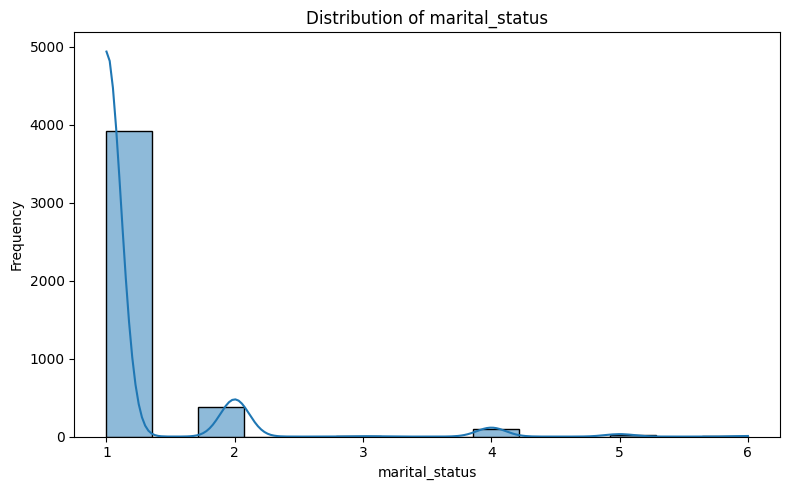

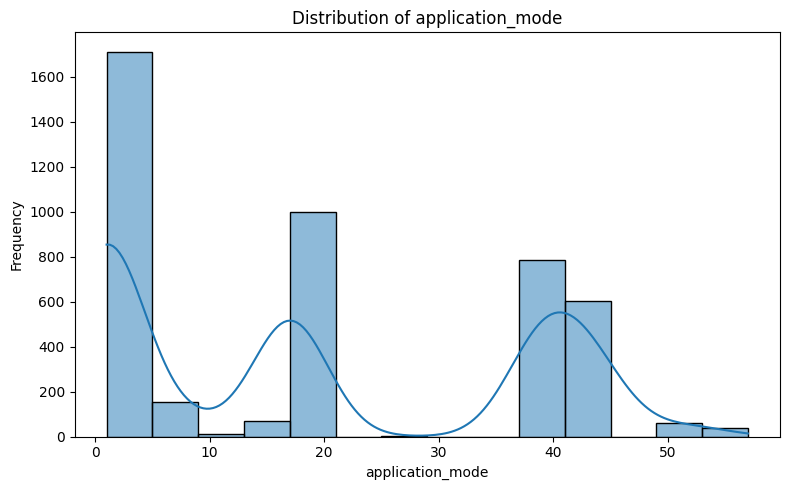

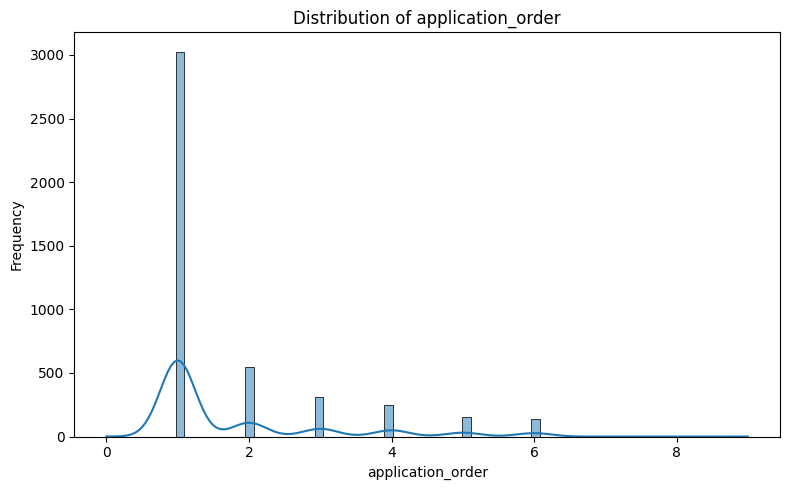

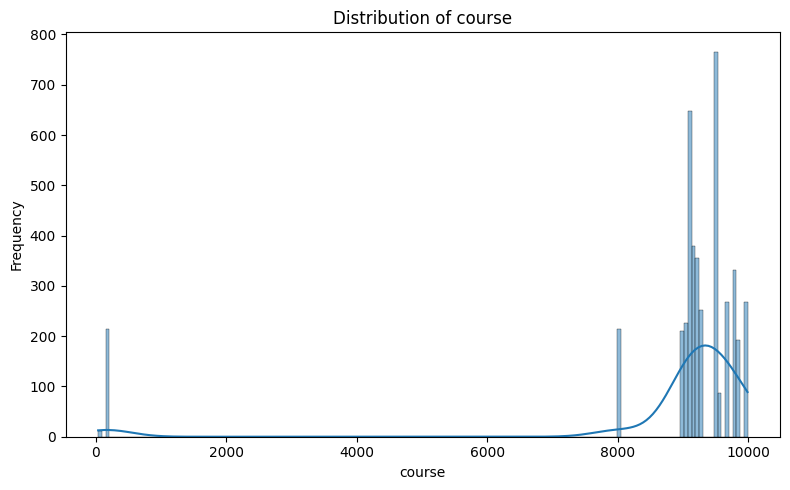

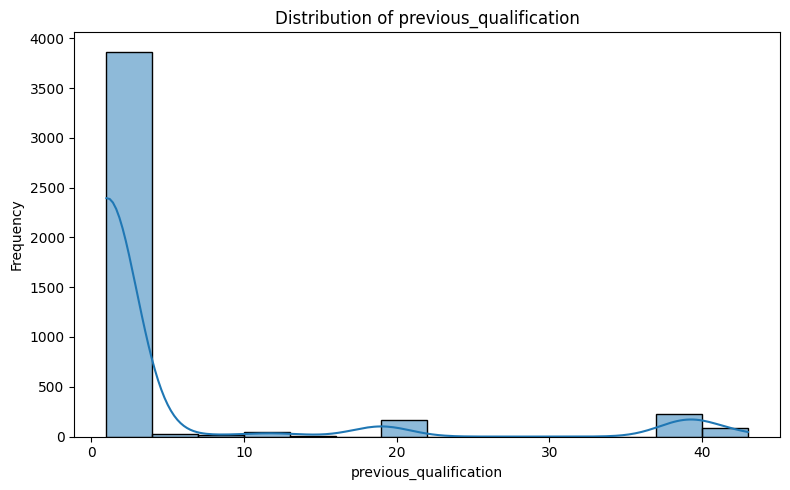

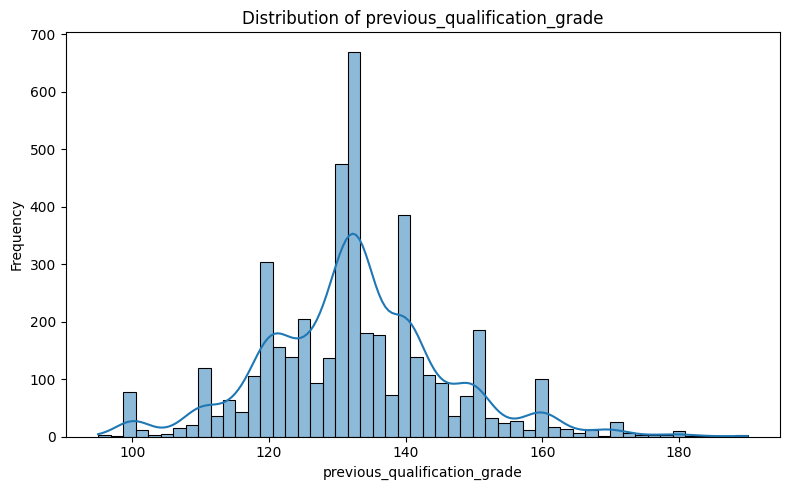

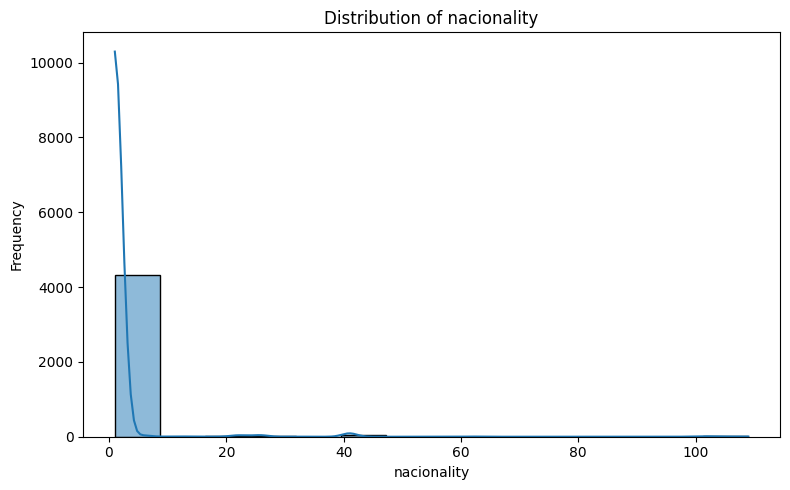

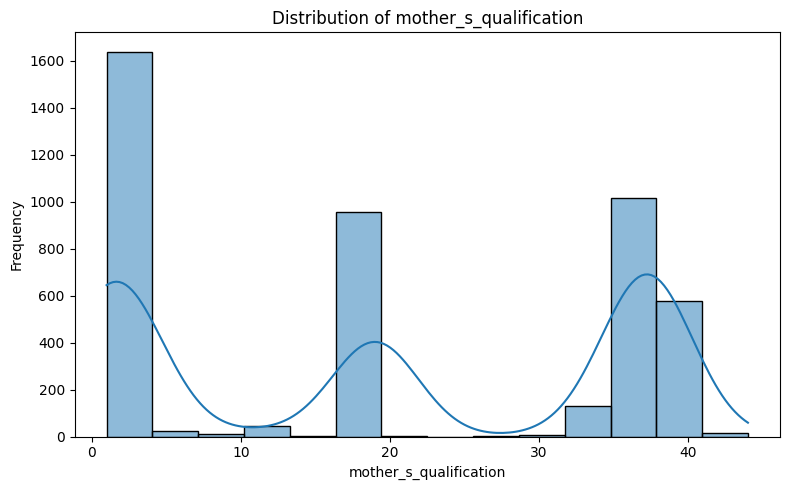

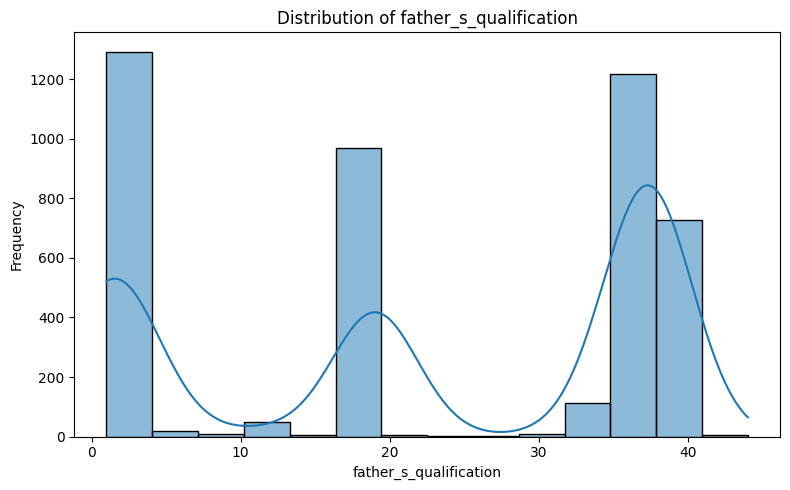

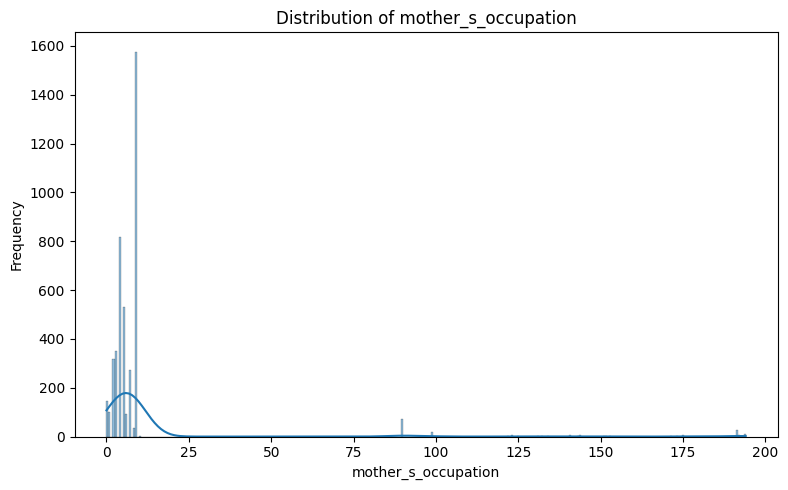

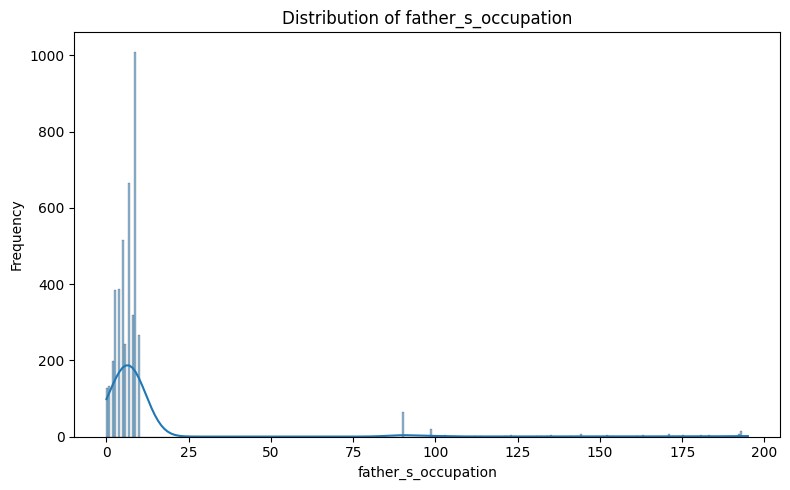

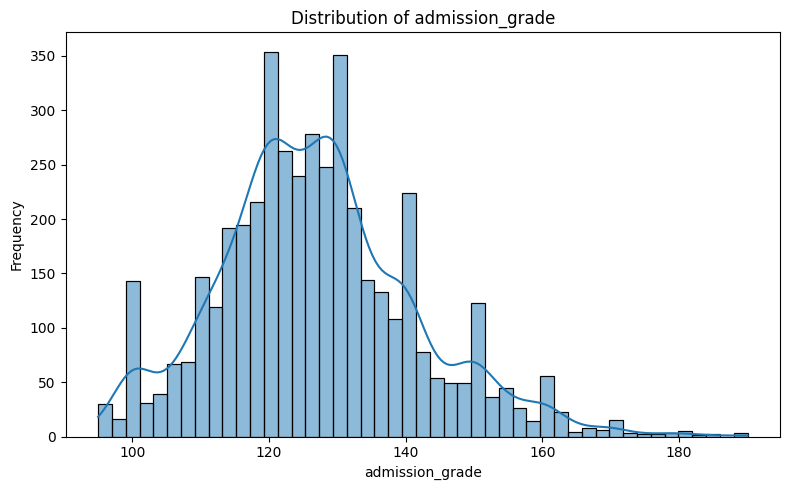

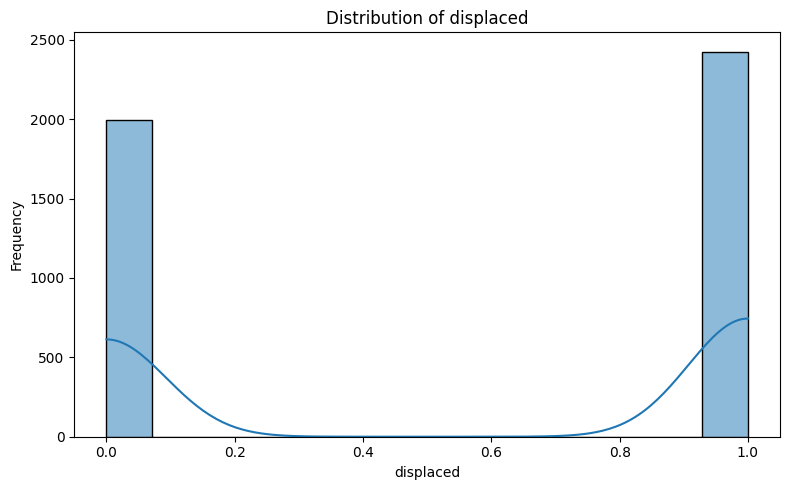

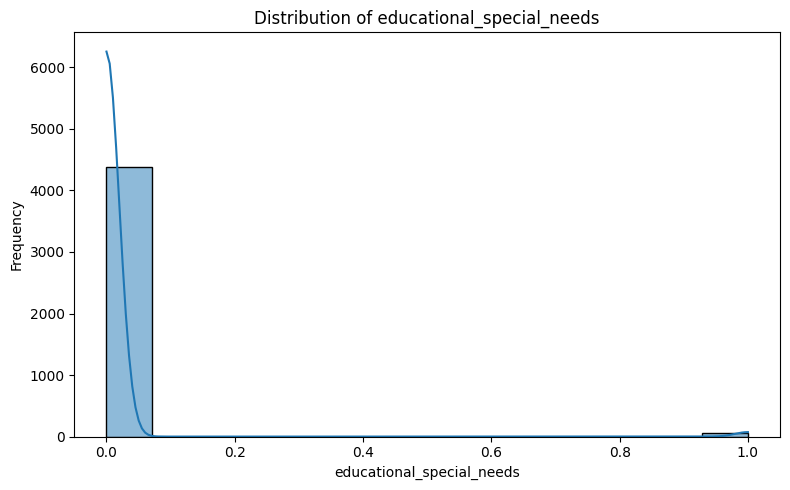

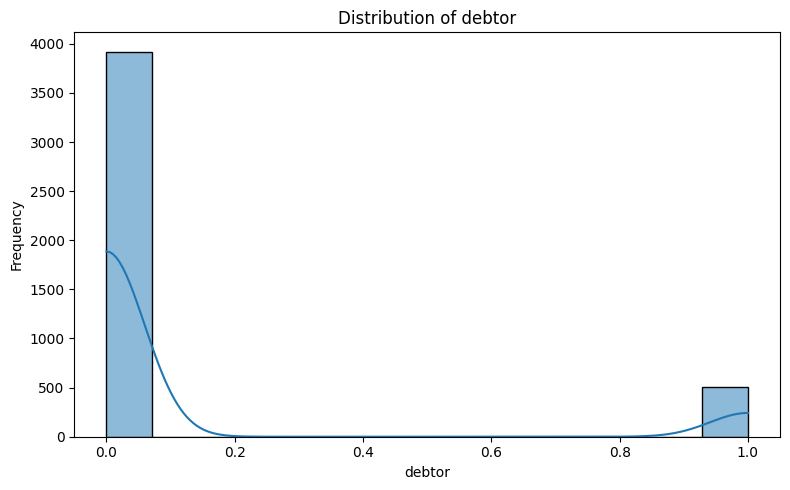

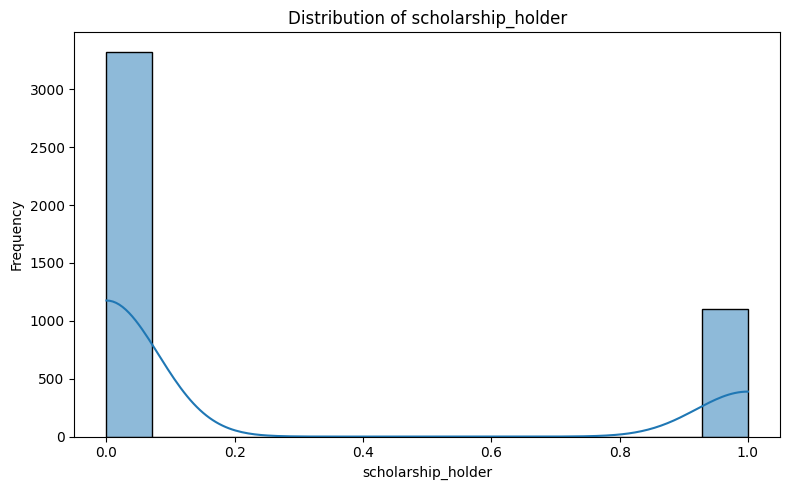

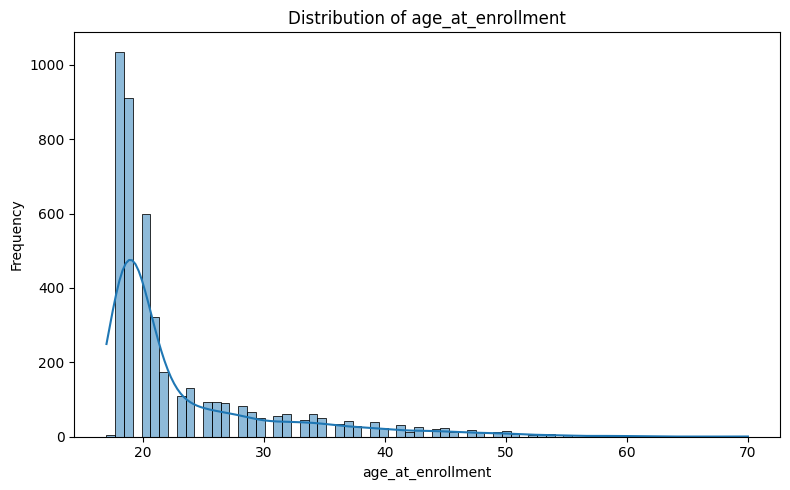

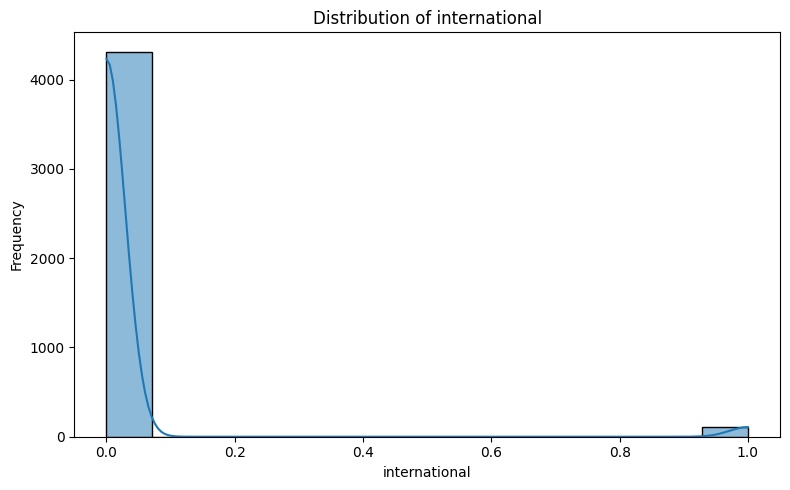

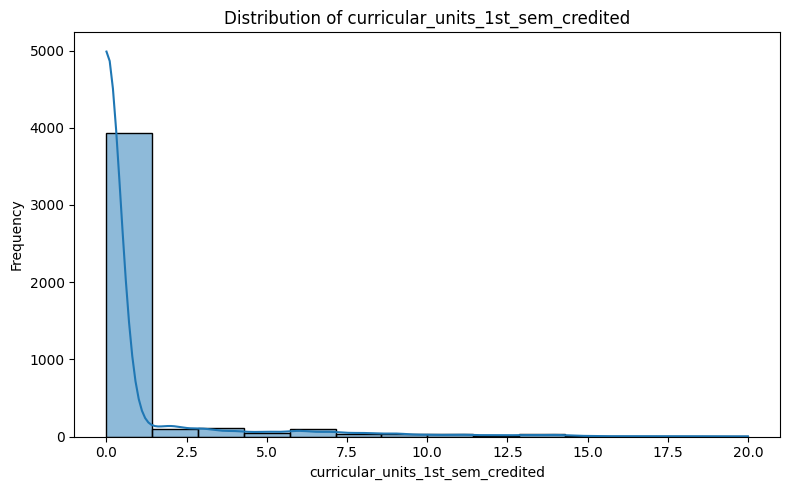

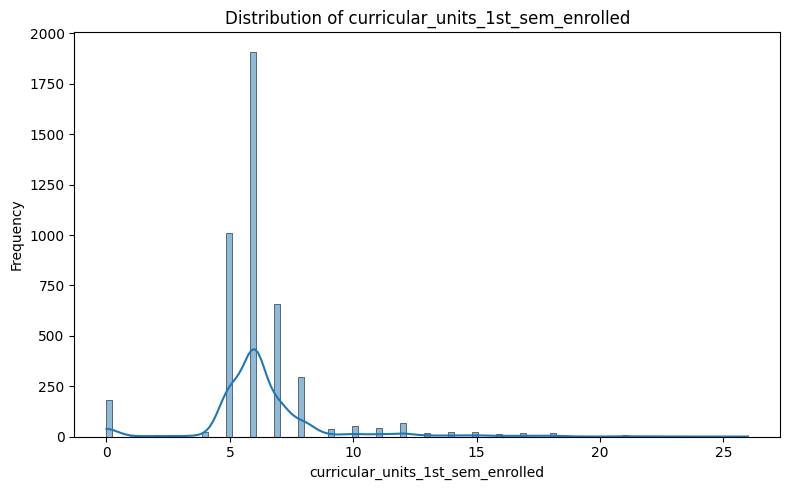

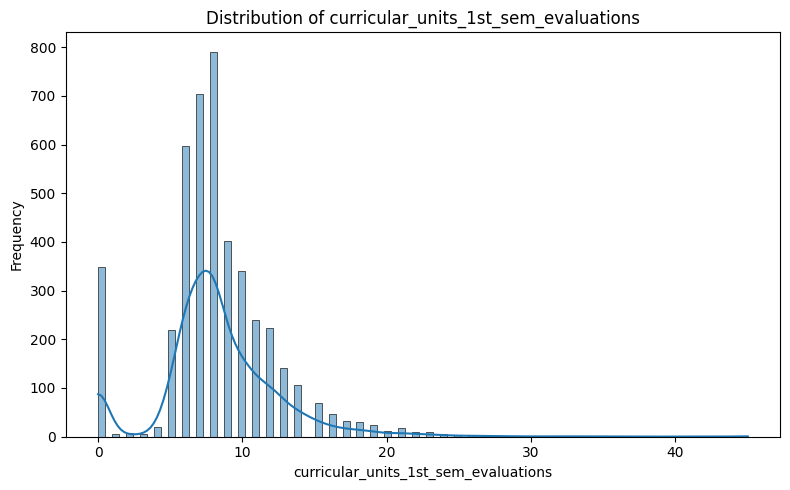

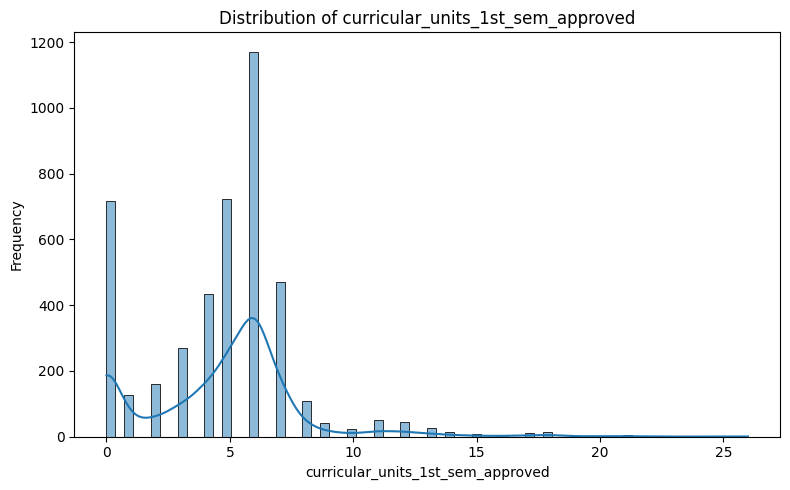

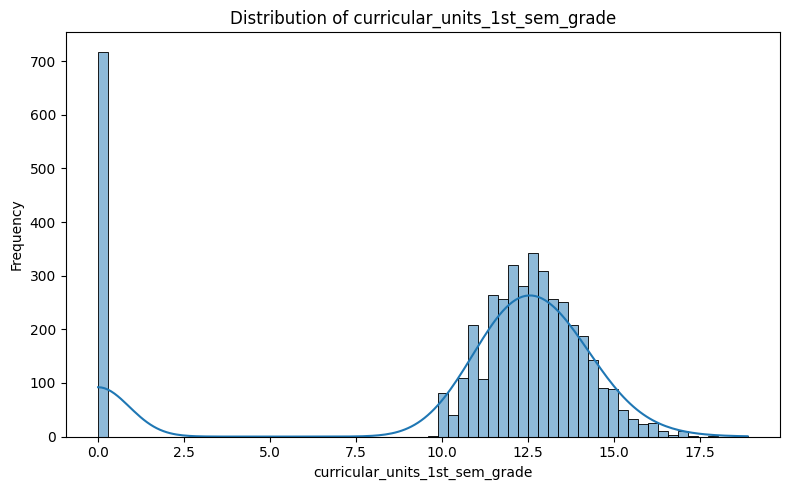

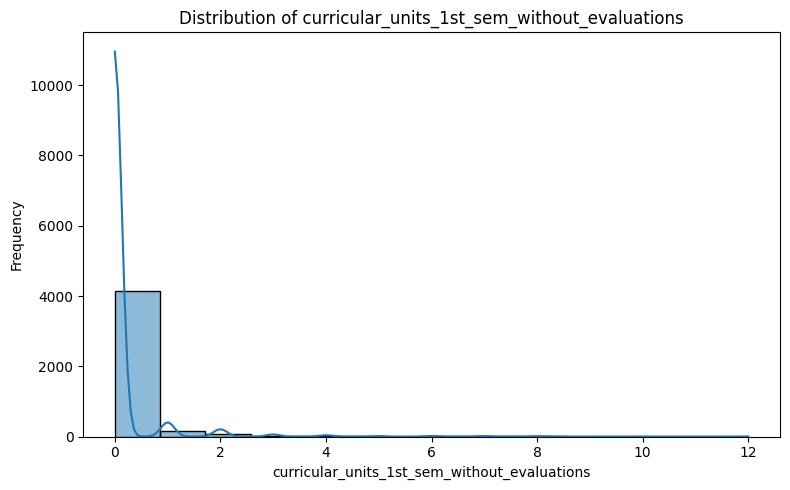

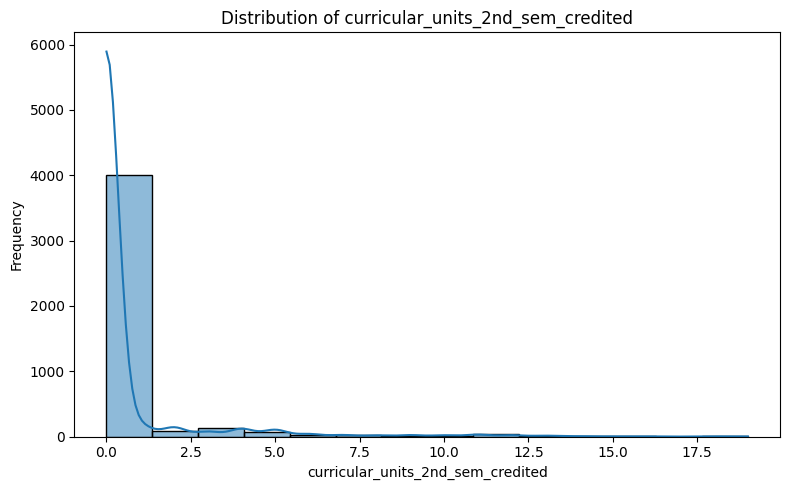

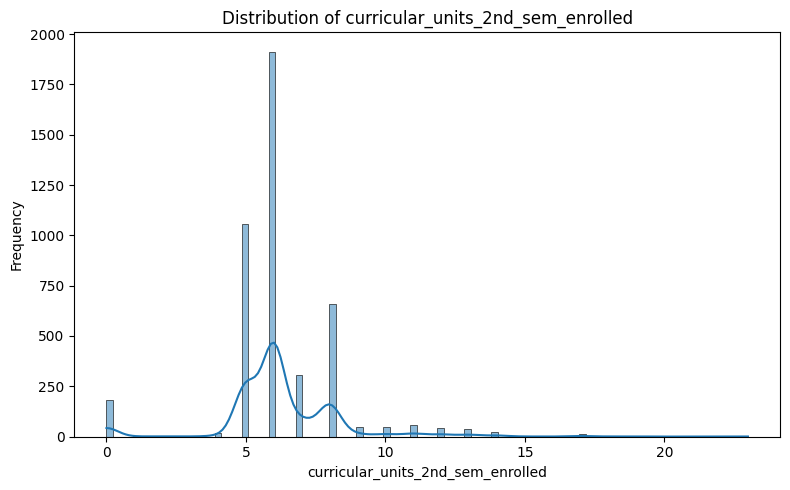

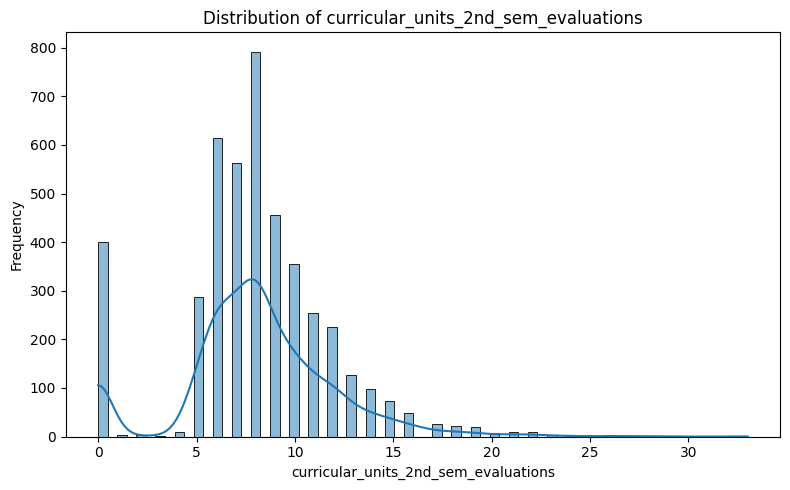

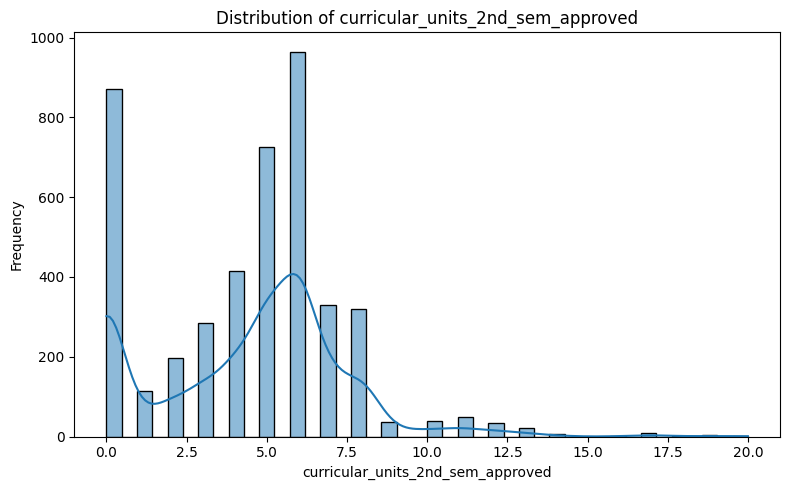

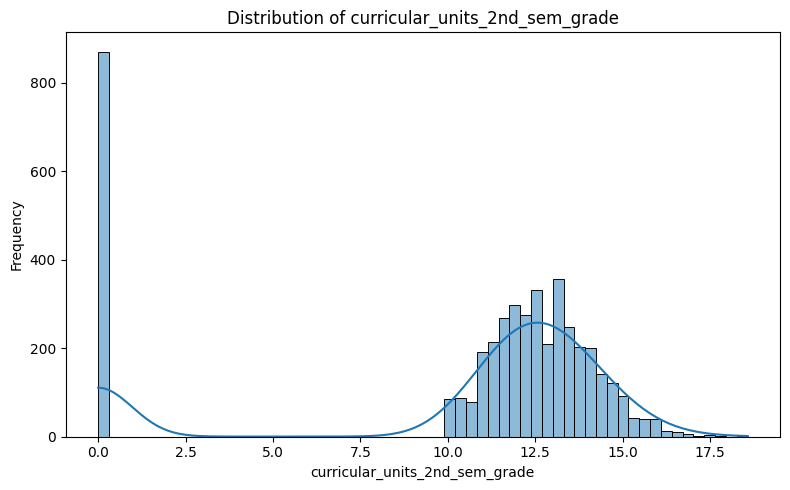

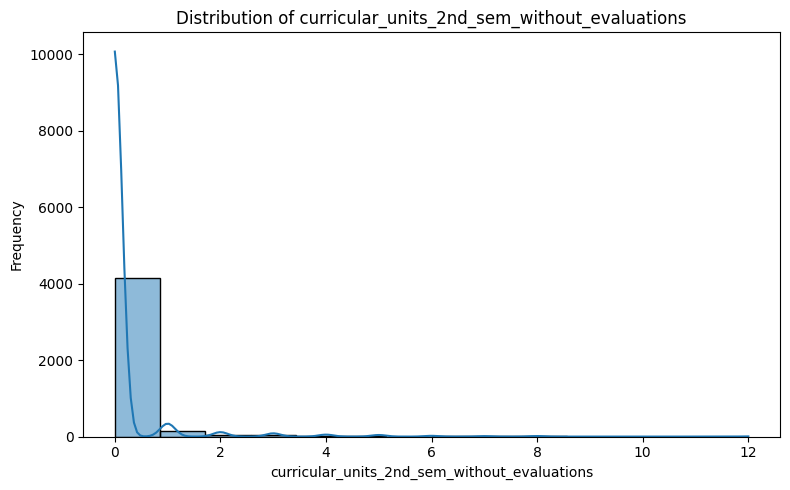

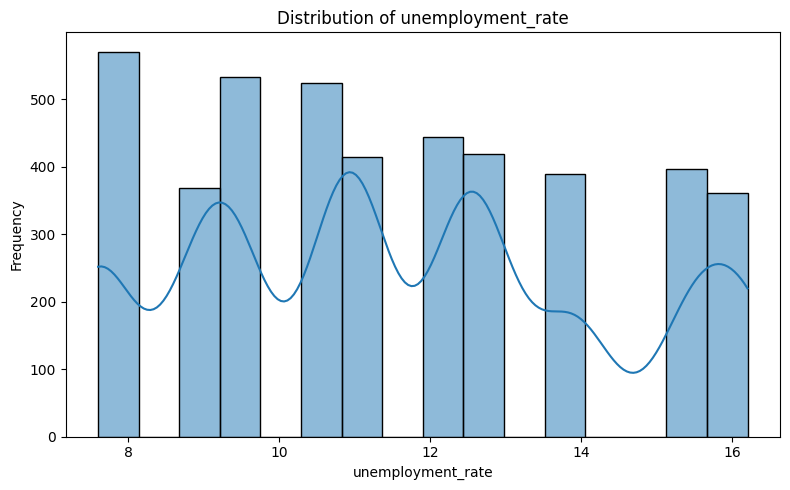

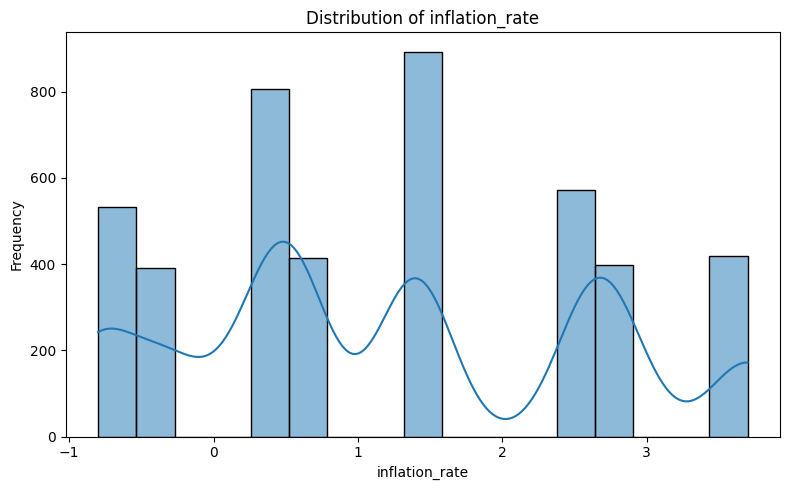

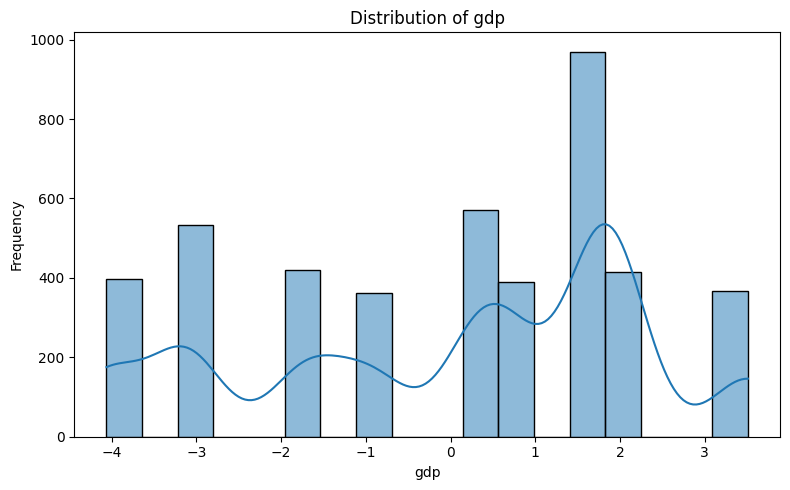

In [52]:
for col in numeric_columns:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()

    filename = (
        PLOT_DIR /
        f"histogram_{col}.png"
    )

    plt.savefig(
        filename,
        dpi=300
    )

    plt.show()

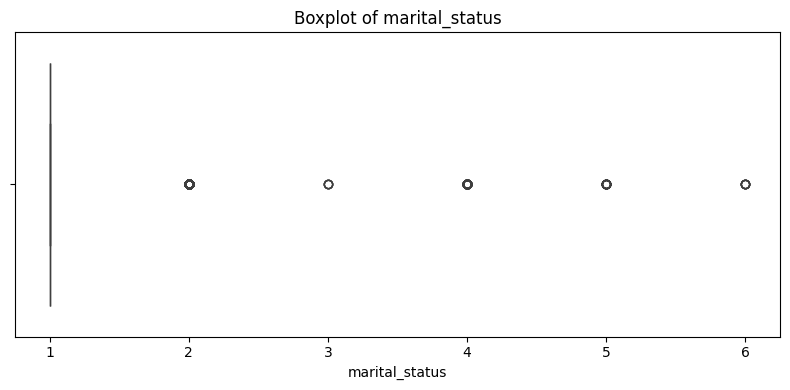

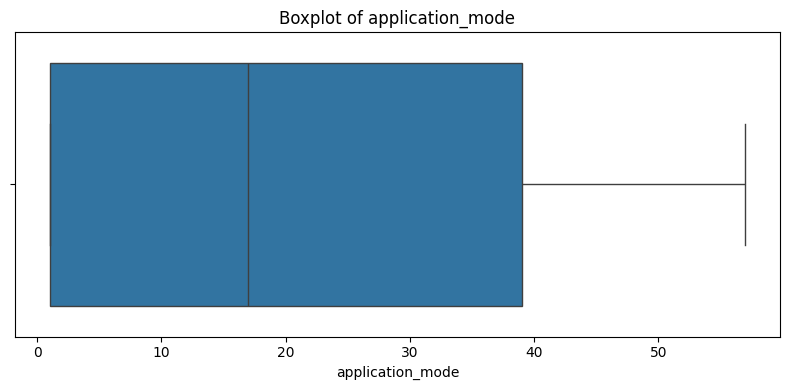

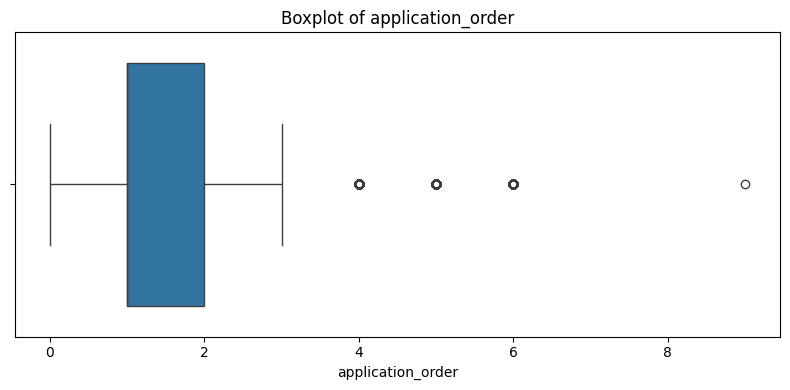

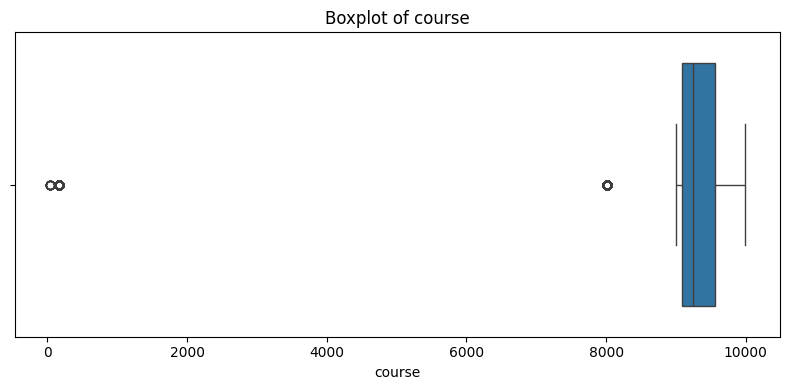

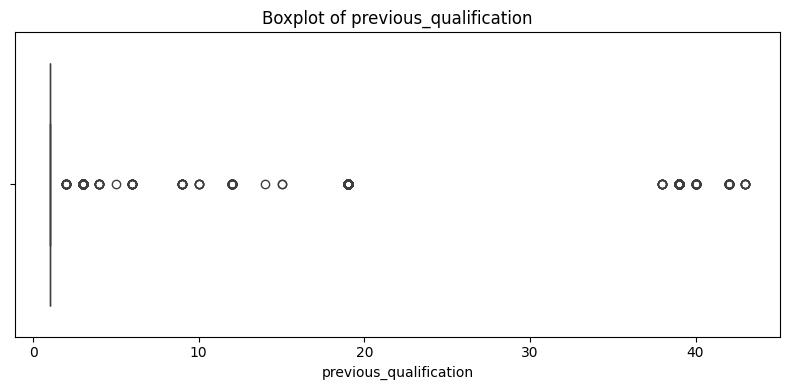

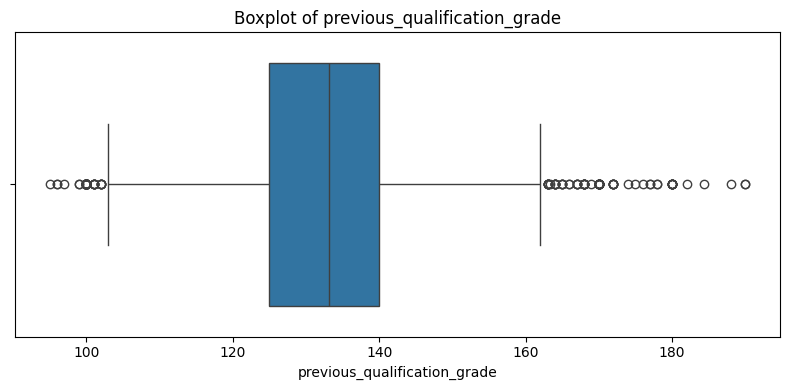

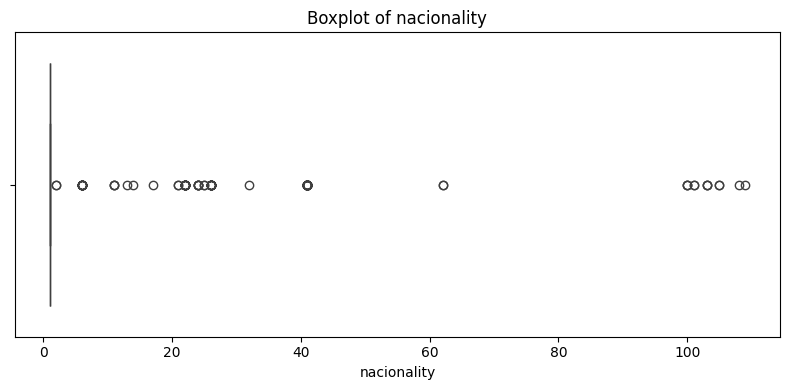

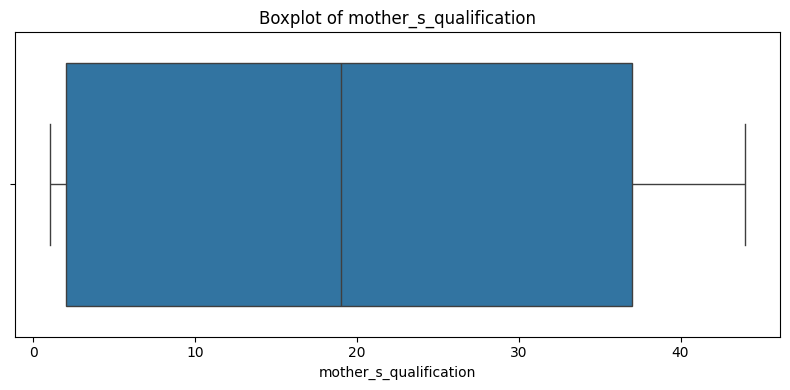

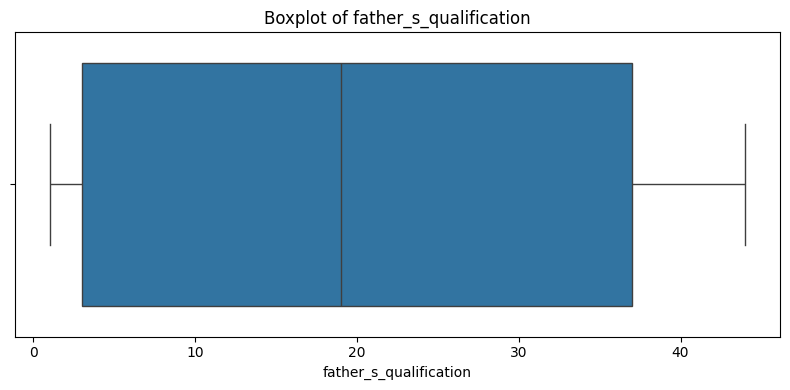

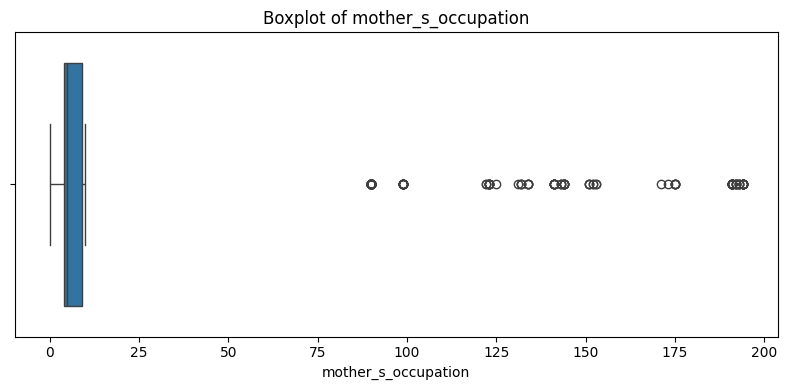

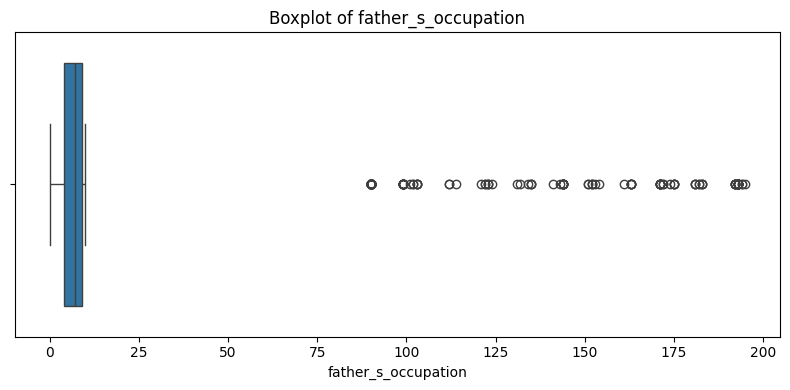

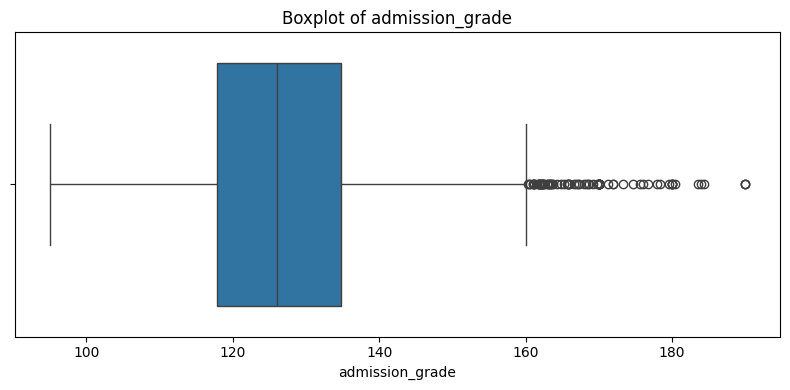

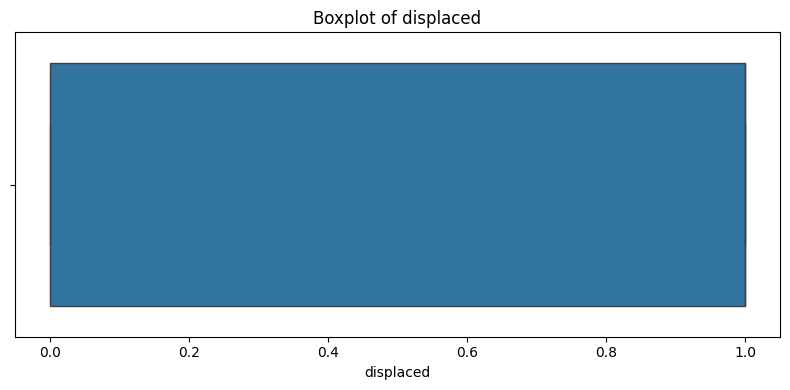

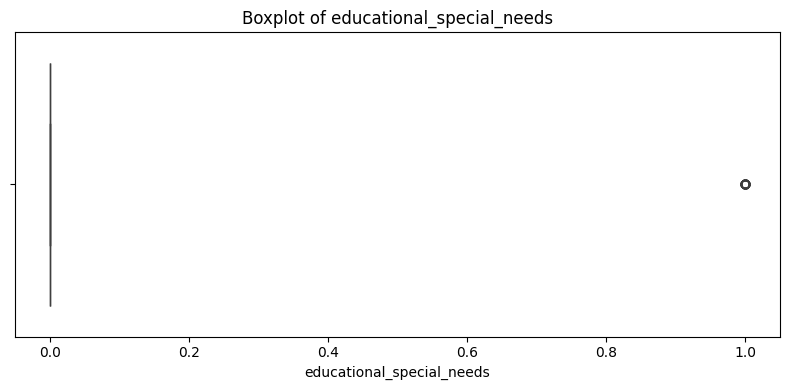

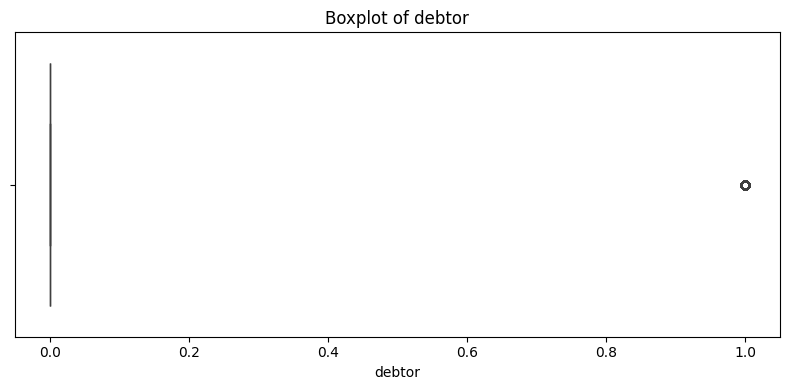

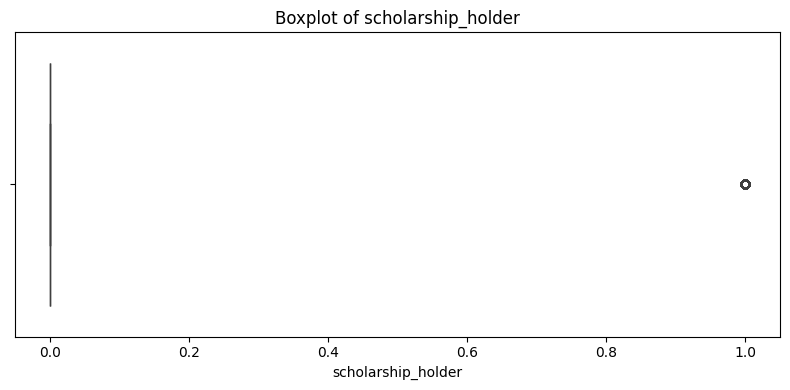

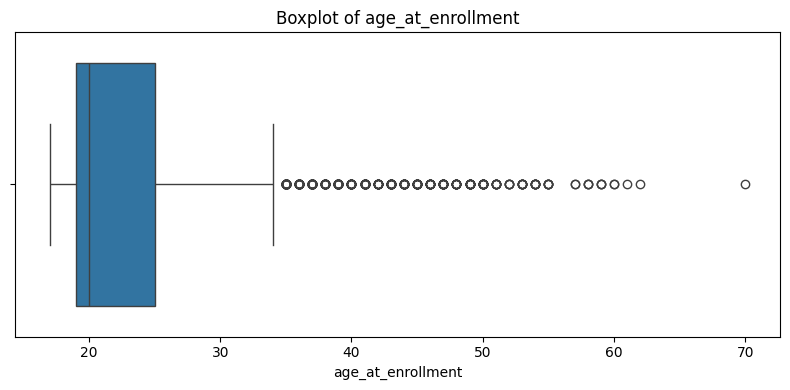

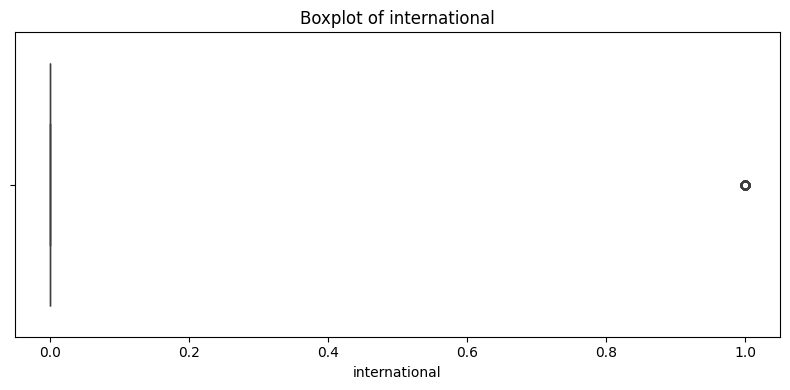

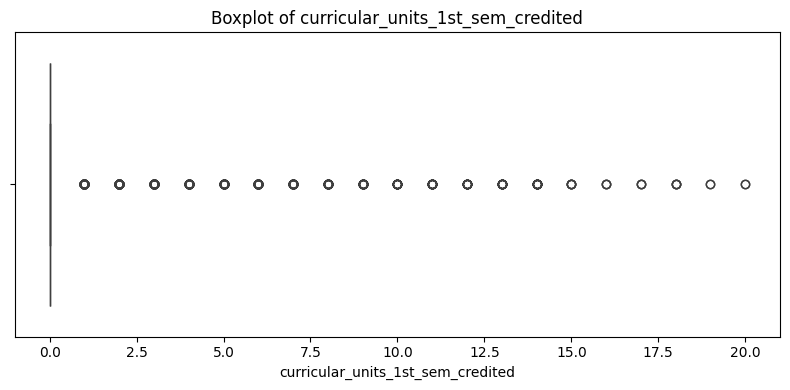

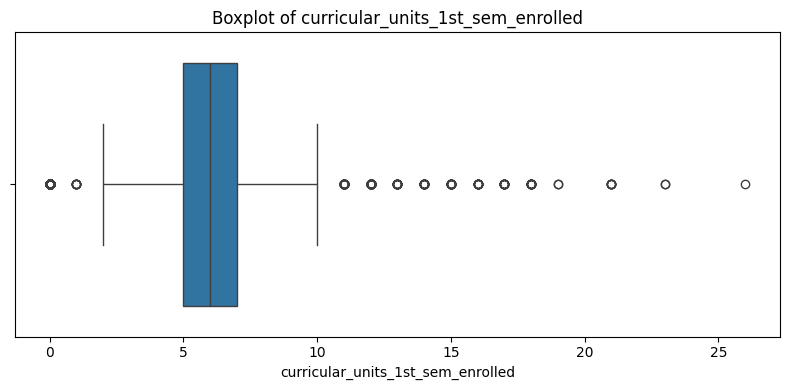

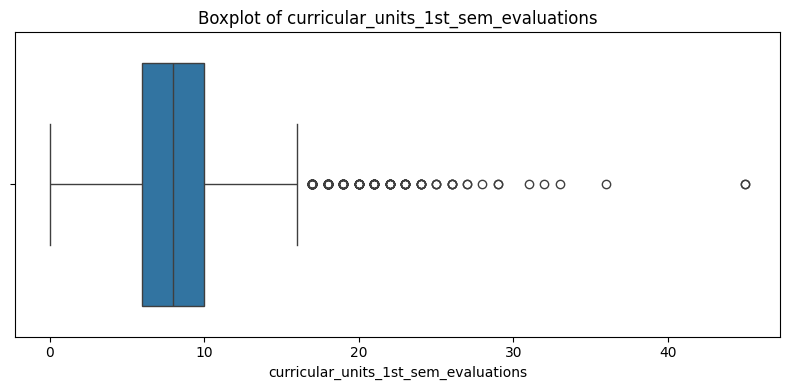

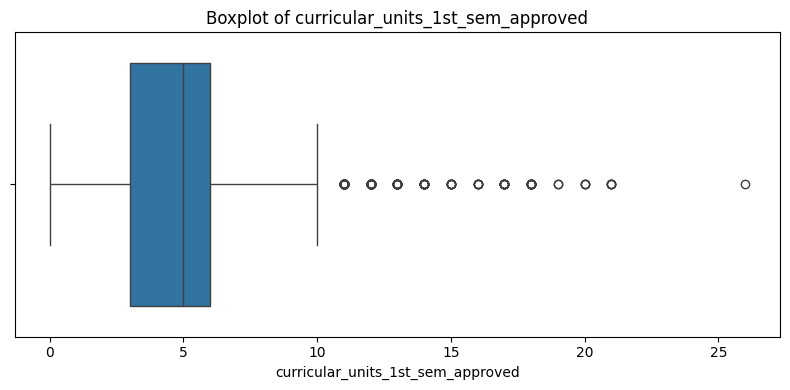

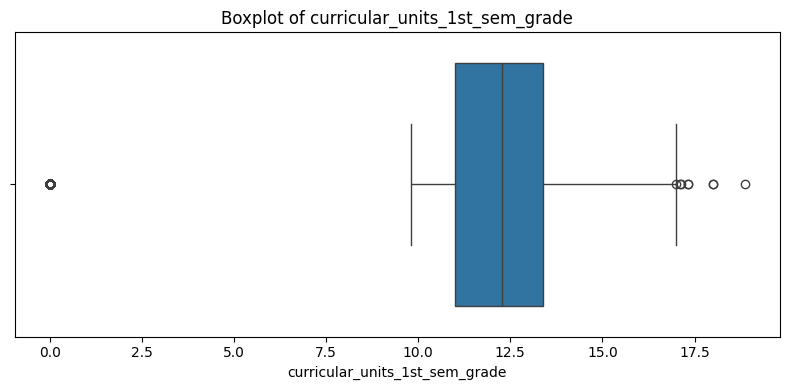

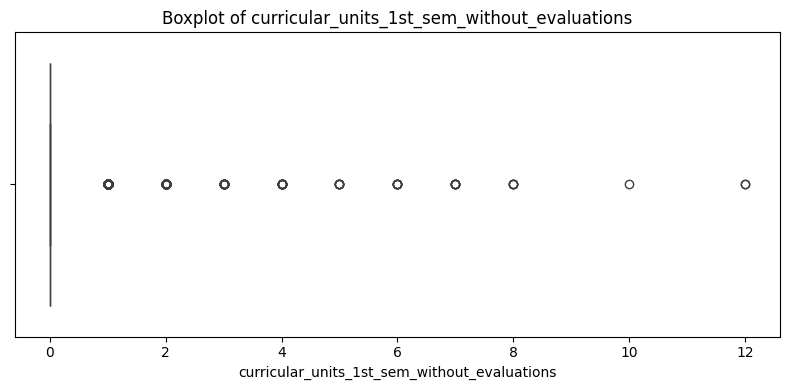

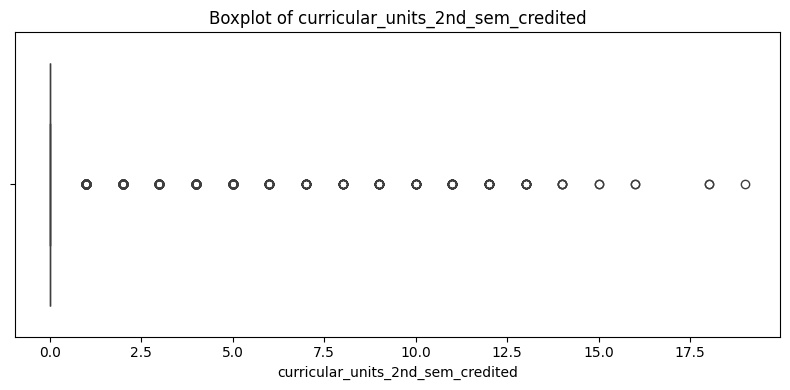

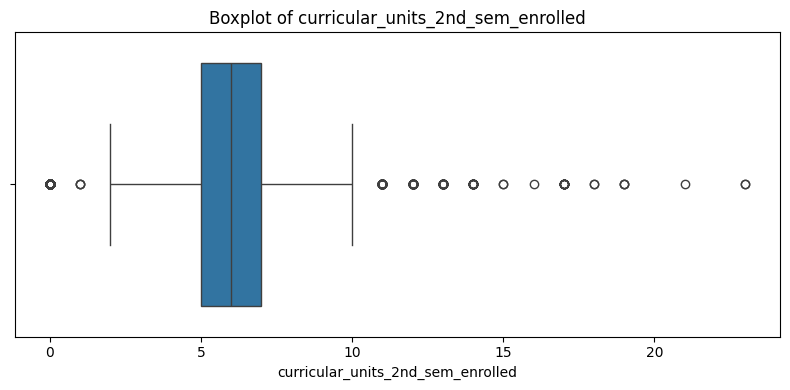

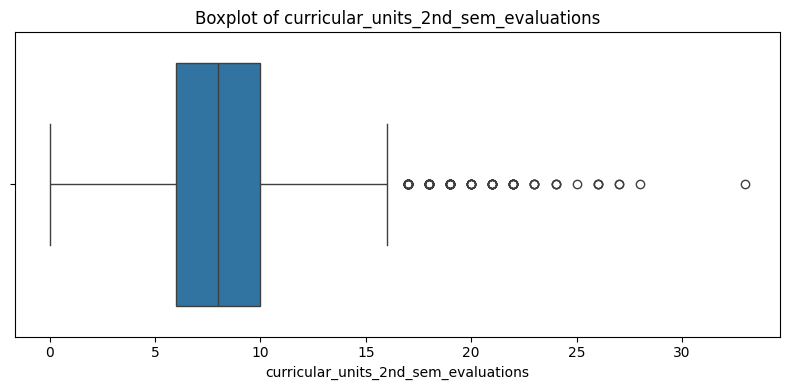

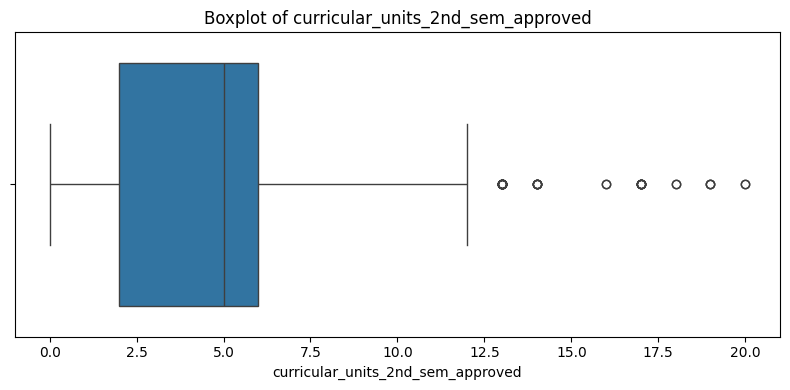

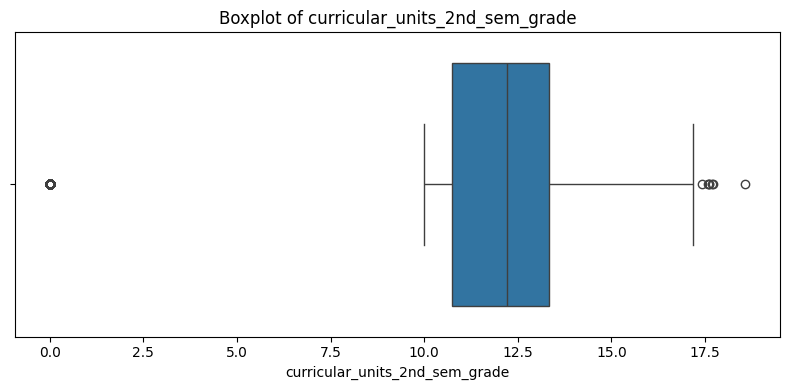

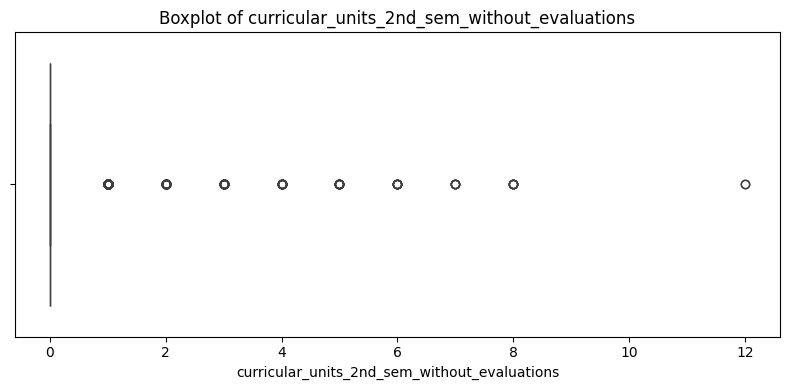

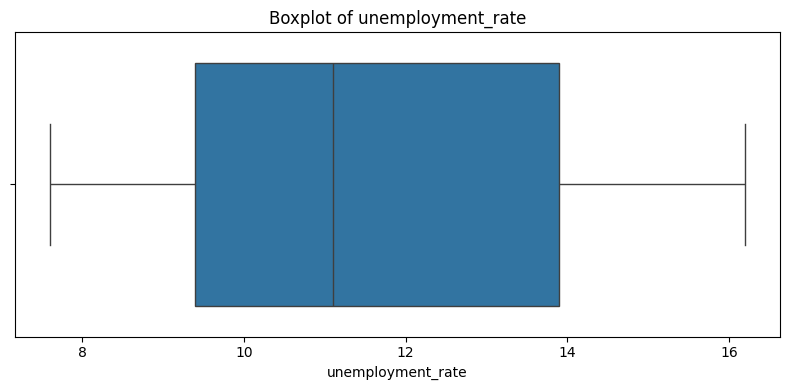

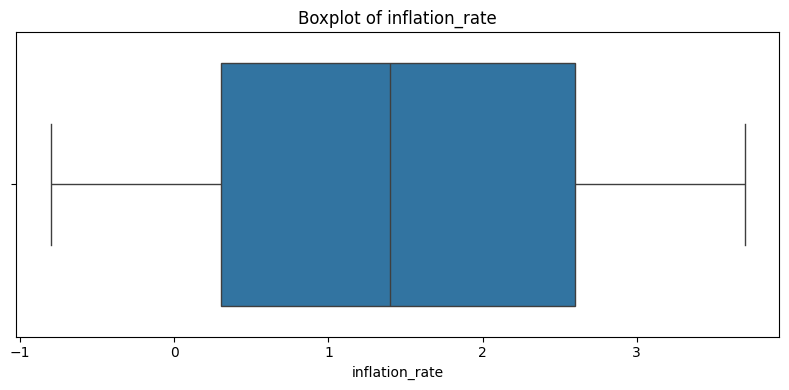

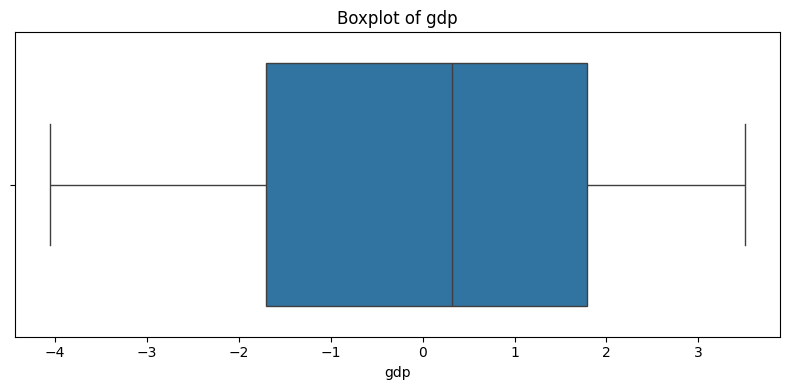

In [53]:
for col in numeric_columns:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)

    plt.tight_layout()

    filename = (
        PLOT_DIR /
        f"boxplot_{col}.png"
    )

    plt.savefig(
        filename,
        dpi=300
    )

    plt.show()

In [54]:
skewness_report = pd.DataFrame({
    "Column": numeric_columns,
    "Skewness": [
        df[col].skew()
        for col in numeric_columns
    ]
})

skewness_report["Absolute_Skewness"] = (
    skewness_report["Skewness"].abs()
)

skewness_report = skewness_report.sort_values(
    "Absolute_Skewness",
    ascending=False
)

display(skewness_report)

,Column,Skewness,Absolute_Skewness
6,nacionality,10.703998,10.703998
13,educational_special_needs,9.154976,9.154976
23,curricular_units_1st_sem_without_evaluations,8.207403,8.207403
29,curricular_units_2nd_sem_without_evaluations,7.267701,7.267701
17,international,6.104830,6.104830
10,father_s_occupation,5.395173,5.395173
9,mother_s_occupation,5.339227,5.339227
24,curricular_units_2nd_sem_credited,4.634820,4.634820
0,marital_status,4.399764,4.399764
18,curricular_units_1st_sem_credited,4.169049,4.169049


In [55]:
outlier_report = []

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    )

    outlier_count = outlier_mask.sum()

    outlier_percentage = (
        outlier_count / len(df) * 100
    )

    outlier_report.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": outlier_count,
        "Outlier_Percentage": outlier_percentage
    })

outlier_report = pd.DataFrame(outlier_report)

display(outlier_report)

,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
0,marital_status,1.00,1.000000,0.000000,1.000,1.000000,505,11.415009
1,application_mode,1.00,39.000000,38.000000,-56.000,96.000000,0,0.000000
2,application_order,1.00,2.000000,1.000000,-0.500,3.500000,541,12.228752
3,course,9085.00,9556.000000,471.000000,8378.500,10262.500000,442,9.990958
4,previous_qualification,1.00,1.000000,0.000000,1.000,1.000000,707,15.981013
5,previous_qualification_grade,125.00,140.000000,15.000000,102.500,162.500000,179,4.046112
6,nacionality,1.00,1.000000,0.000000,1.000,1.000000,110,2.486438
7,mother_s_qualification,2.00,37.000000,35.000000,-50.500,89.500000,0,0.000000
8,father_s_qualification,3.00,37.000000,34.000000,-48.000,88.000000,0,0.000000
9,mother_s_occupation,4.00,9.000000,5.000000,-3.500,16.500000,182,4.113924


In [56]:
outlier_report.to_csv(
    REPORT_DIR / "outlier_report_before.csv",
    index=False
)

In [57]:
outlier_records = {}

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    )

    outlier_records[col] = df.loc[mask]

for col, records in outlier_records.items():

    if len(records) > 0:

        print("\n" + "=" * 70)
        print(f"Outliers in: {col}")
        display(records.head(20))


Outliers in: marital_status


,marital_status,application_mode,application_order,course,daytime_evening_attendance,previous_qualification,previous_qualification_grade,nacionality,mother_s_qualification,father_s_qualification,...,curricular_units_2nd_sem_credited,curricular_units_2nd_sem_enrolled,curricular_units_2nd_sem_evaluations,curricular_units_2nd_sem_approved,curricular_units_2nd_sem_grade,curricular_units_2nd_sem_without_evaluations,unemployment_rate,inflation_rate,gdp,target
4,2,39,1,8014,1970-01-01 00:00:00.000000000,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
5,2,39,1,9991,1970-01-01 00:00:00.000000000,19,133.1,1,37,37,...,0,5,17,5,11.500000,5,16.2,0.3,-0.92,Graduate
38,4,39,1,9991,1970-01-01 00:00:00.000000000,1,120.0,1,19,19,...,0,5,5,5,11.600000,0,7.6,2.6,0.32,Graduate
56,2,7,1,9254,1970-01-01 00:00:00.000000001,3,130.0,1,1,3,...,0,6,6,0,0.000000,0,12.4,0.5,1.79,Dropout
65,4,42,1,9500,1970-01-01 00:00:00.000000001,19,133.1,1,1,1,...,1,8,10,5,11.000000,0,13.9,-0.3,0.79,Dropout
79,2,39,1,8014,1970-01-01 00:00:00.000000000,1,120.0,1,37,37,...,0,6,6,6,11.666667,0,10.8,1.4,1.74,Graduate
84,2,39,1,8014,1970-01-01 00:00:00.000000000,1,130.0,1,37,37,...,0,6,11,5,11.000000,0,9.4,-0.8,-3.12,Graduate
93,2,39,1,9853,1970-01-01 00:00:00.000000001,10,133.1,1,37,34,...,0,6,14,0,0.000000,1,7.6,2.6,0.32,Dropout
94,2,39,1,8014,1970-01-01 00:00:00.000000000,1,133.1,1,37,19,...,0,6,7,6,12.333333,0,12.7,3.7,-1.70,Graduate
102,2,39,1,8014,1970-01-01 00:00:00.000000000,1,130.0,1,37,37,...,0,6,0,0,0.000000,0,9.4,-0.8,-3.12,Dropout



Outliers in: application_order


,marital_status,application_mode,application_order,course,daytime_evening_attendance,previous_qualification,previous_qualification_grade,nacionality,mother_s_qualification,father_s_qualification,...,curricular_units_2nd_sem_credited,curricular_units_2nd_sem_enrolled,curricular_units_2nd_sem_evaluations,curricular_units_2nd_sem_approved,curricular_units_2nd_sem_grade,curricular_units_2nd_sem_without_evaluations,unemployment_rate,inflation_rate,gdp,target
0,1,17,5,171,1970-01-01 00:00:00.000000001,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
2,1,1,5,9070,1970-01-01 00:00:00.000000001,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
7,1,18,4,9254,1970-01-01 00:00:00.000000001,1,119.0,1,37,37,...,0,5,5,0,0.000000,0,15.5,2.8,-4.06,Dropout
21,1,18,4,9556,1970-01-01 00:00:00.000000001,1,127.0,1,1,38,...,0,8,9,8,11.425000,0,12.7,3.7,-1.70,Enrolled
22,1,1,4,9500,1970-01-01 00:00:00.000000001,1,142.0,1,19,19,...,0,8,12,7,12.857143,0,12.7,3.7,-1.70,Graduate
23,1,1,4,9670,1970-01-01 00:00:00.000000001,1,125.0,1,1,38,...,0,6,7,6,12.285714,0,11.1,0.6,2.02,Graduate
40,1,1,5,9773,1970-01-01 00:00:00.000000001,1,126.0,1,3,3,...,0,5,5,0,0.000000,0,12.7,3.7,-1.70,Dropout
42,1,1,6,9500,1970-01-01 00:00:00.000000001,1,103.0,1,1,3,...,0,8,9,7,14.342857,0,11.1,0.6,2.02,Graduate
47,1,17,6,9500,1970-01-01 00:00:00.000000001,1,132.0,1,37,19,...,0,8,9,7,13.771429,0,11.1,0.6,2.02,Graduate
73,1,17,4,9254,1970-01-01 00:00:00.000000001,1,118.0,1,38,37,...,0,6,12,1,12.000000,0,12.4,0.5,1.79,Dropout



Outliers in: course


...

,marital_status,application_mode,application_order,course,daytime_evening_attendance,previous_qualification,previous_qualification_grade,nacionality,mother_s_qualification,father_s_qualification,...,curricular_units_2nd_sem_credited,curricular_units_2nd_sem_enrolled,curricular_units_2nd_sem_evaluations,curricular_units_2nd_sem_approved,curricular_units_2nd_sem_grade,curricular_units_2nd_sem_without_evaluations,unemployment_rate,inflation_rate,gdp,target
103,4,39,1,9003,1970-01-01 00:00:00.000000001,12,133.1,1,37,37,...,10,13,14,13,14.230769,1,15.5,2.8,-4.06,Graduate
180,1,43,1,9853,1970-01-01 00:00:00.000000001,1,140.0,1,3,1,...,13,19,19,19,12.789474,0,12.4,0.5,1.79,Graduate
467,1,43,6,9238,1970-01-01 00:00:00.000000001,1,129.0,1,34,34,...,11,13,15,13,13.266667,0,9.4,-0.8,-3.12,Graduate
599,1,17,1,9003,1970-01-01 00:00:00.000000001,1,133.0,1,38,37,...,11,13,13,13,11.461538,0,15.5,2.8,-4.06,Graduate
669,1,42,1,9500,1970-01-01 00:00:00.000000001,1,100.0,1,19,37,...,11,17,19,17,13.554737,0,16.2,0.3,-0.92,Graduate
691,2,43,1,9003,1970-01-01 00:00:00.000000001,1,133.1,1,37,37,...,12,13,13,13,12.384615,0,15.5,2.8,-4.06,Graduate
707,2,39,1,9003,1970-01-01 00:00:00.000000001,1,150.0,1,37,37,...,11,13,13,13,14.230769,0,15.5,2.8,-4.06,Graduate
894,1,42,1,9085,1970-01-01 00:00:00.000000001,39,150.0,1,1,1,...,9,13,27,13,12.461538,5,15.5,2.8,-4.06,Graduate
961,1,43,1,9147,1970-01-01 00:00:00.000000001,1,141.0,1,37,37,...,10,14,14,14,13.642857,0,9.4,-0.8,-3.12,Graduate
1194,2,39,1,9003,1970-01-01 00:00:00.000000001,1,130.0,1,38,37,...,11,13,13,13,15.307692,0,15.5,2.8,-4.06,Graduate



Outliers in: curricular_units_2nd_sem_grade


,marital_status,application_mode,application_order,course,daytime_evening_attendance,previous_qualification,previous_qualification_grade,nacionality,mother_s_qualification,father_s_qualification,...,curricular_units_2nd_sem_credited,curricular_units_2nd_sem_enrolled,curricular_units_2nd_sem_evaluations,curricular_units_2nd_sem_approved,curricular_units_2nd_sem_grade,curricular_units_2nd_sem_without_evaluations,unemployment_rate,inflation_rate,gdp,target
0,1,17,5,171,1970-01-01 00:00:00.000000001,1,122.0,1,19,12,...,0,0,0,0,0.0,0,10.8,1.4,1.74,Dropout
2,1,1,5,9070,1970-01-01 00:00:00.000000001,1,122.0,1,37,37,...,0,6,0,0,0.0,0,10.8,1.4,1.74,Dropout
7,1,18,4,9254,1970-01-01 00:00:00.000000001,1,119.0,1,37,37,...,0,5,5,0,0.0,0,15.5,2.8,-4.06,Dropout
12,1,1,2,9853,1970-01-01 00:00:00.000000001,1,133.0,1,19,37,...,0,6,0,0,0.0,0,12.7,3.7,-1.70,Dropout
15,1,1,1,9773,1970-01-01 00:00:00.000000001,1,127.0,1,19,37,...,0,6,7,0,0.0,0,15.5,2.8,-4.06,Dropout
20,1,1,3,171,1970-01-01 00:00:00.000000001,1,122.0,1,1,1,...,0,0,0,0,0.0,0,11.1,0.6,2.02,Graduate
36,1,39,1,9119,1970-01-01 00:00:00.000000001,10,133.1,1,34,37,...,0,5,0,0,0.0,0,7.6,2.6,0.32,Dropout
40,1,1,5,9773,1970-01-01 00:00:00.000000001,1,126.0,1,3,3,...,0,5,5,0,0.0,0,12.7,3.7,-1.70,Dropout
44,1,39,1,9991,1970-01-01 00:00:00.000000000,1,133.1,1,37,37,...,0,5,0,0,0.0,0,16.2,0.3,-0.92,Dropout
56,2,7,1,9254,1970-01-01 00:00:00.000000001,3,130.0,1,1,3,...,0,6,6,0,0.0,0,12.4,0.5,1.79,Dropout



Outliers in: curricular_units_2nd_sem_without_evaluations


,marital_status,application_mode,application_order,course,daytime_evening_attendance,previous_qualification,previous_qualification_grade,nacionality,mother_s_qualification,father_s_qualification,...,curricular_units_2nd_sem_credited,curricular_units_2nd_sem_enrolled,curricular_units_2nd_sem_evaluations,curricular_units_2nd_sem_approved,curricular_units_2nd_sem_grade,curricular_units_2nd_sem_without_evaluations,unemployment_rate,inflation_rate,gdp,target
5,2,39,1,9991,1970-01-01 00:00:00.000000000,19,133.1,1,37,37,...,0,5,17,5,11.500000,5,16.2,0.3,-0.92,Graduate
18,1,1,1,9130,1970-01-01 00:00:00.000000001,1,137.0,1,3,19,...,0,5,8,4,12.250000,2,10.8,1.4,1.74,Graduate
37,1,43,1,9147,1970-01-01 00:00:00.000000001,1,140.0,1,37,37,...,0,5,8,2,12.000000,2,16.2,0.3,-0.92,Dropout
45,1,17,1,9991,1970-01-01 00:00:00.000000000,1,154.0,1,38,38,...,0,5,11,3,14.333333,1,7.6,2.6,0.32,Enrolled
68,1,1,3,9147,1970-01-01 00:00:00.000000001,1,125.0,1,1,38,...,0,5,10,4,10.750000,3,16.2,0.3,-0.92,Dropout
93,2,39,1,9853,1970-01-01 00:00:00.000000001,10,133.1,1,37,34,...,0,6,14,0,0.000000,1,7.6,2.6,0.32,Dropout
103,4,39,1,9003,1970-01-01 00:00:00.000000001,12,133.1,1,37,37,...,10,13,14,13,14.230769,1,15.5,2.8,-4.06,Graduate
114,1,17,2,9500,1970-01-01 00:00:00.000000001,1,122.0,1,37,37,...,0,7,7,6,12.516667,1,7.6,2.6,0.32,Dropout
121,1,1,2,9147,1970-01-01 00:00:00.000000001,1,120.0,1,19,19,...,0,5,9,4,11.250000,2,16.2,0.3,-0.92,Graduate
181,1,44,1,9991,1970-01-01 00:00:00.000000000,39,140.0,1,37,19,...,2,6,7,6,13.166667,1,9.4,-0.8,-3.12,Enrolled


In [58]:
EXCLUDE_OUTLIER_COLS = [
    # "id",
    # "student_id",
    # "customer_id"
]

OUTLIER_COLS = [
    col for col in numeric_columns
    if col not in EXCLUDE_OUTLIER_COLS
]

print("Columns selected for outlier treatment:")
print(OUTLIER_COLS)

Columns selected for outlier treatment:
['marital_status', 'application_mode', 'application_order', 'course', 'previous_qualification', 'previous_qualification_grade', 'nacionality', 'mother_s_qualification', 'father_s_qualification', 'mother_s_occupation', 'father_s_occupation', 'admission_grade', 'displaced', 'educational_special_needs', 'debtor', 'scholarship_holder', 'age_at_enrollment', 'international', 'curricular_units_1st_sem_credited', 'curricular_units_1st_sem_enrolled', 'curricular_units_1st_sem_evaluations', 'curricular_units_1st_sem_approved', 'curricular_units_1st_sem_grade', 'curricular_units_1st_sem_without_evaluations', 'curricular_units_2nd_sem_credited', 'curricular_units_2nd_sem_enrolled', 'curricular_units_2nd_sem_evaluations', 'curricular_units_2nd_sem_approved', 'curricular_units_2nd_sem_grade', 'curricular_units_2nd_sem_without_evaluations', 'unemployment_rate', 'inflation_rate', 'gdp']


In [59]:
outlier_treatment_summary = []

for col in OUTLIER_COLS:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    below_count = (
        df[col] < lower_bound
    ).sum()

    above_count = (
        df[col] > upper_bound
    ).sum()

    df[col] = df[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )

    outlier_treatment_summary.append({
        "Column": col,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Lower_Values_Capped": below_count,
        "Upper_Values_Capped": above_count,
        "Total_Capped":
            below_count + above_count
    })

outlier_treatment_summary = pd.DataFrame(
    outlier_treatment_summary
)

display(outlier_treatment_summary)

,Column,Lower_Bound,Upper_Bound,Lower_Values_Capped,Upper_Values_Capped,Total_Capped
0,marital_status,1.000,1.000000,0,505,505
1,application_mode,-56.000,96.000000,0,0,0
2,application_order,-0.500,3.500000,0,541,541
3,course,8378.500,10262.500000,442,0,442
4,previous_qualification,1.000,1.000000,0,707,707
5,previous_qualification_grade,102.500,162.500000,93,86,179
6,nacionality,1.000,1.000000,0,110,110
7,mother_s_qualification,-50.500,89.500000,0,0,0
8,father_s_qualification,-48.000,88.000000,0,0,0
9,mother_s_occupation,-3.500,16.500000,0,182,182


In [60]:
outlier_treatment_summary.to_csv(
    REPORT_DIR / "outlier_treatment_summary.csv",
    index=False
)

In [61]:
outlier_report_after = []

for col in OUTLIER_COLS:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    )

    count = mask.sum()

    outlier_report_after.append({
        "Column": col,
        "Remaining_Outliers": count
    })

outlier_report_after = pd.DataFrame(
    outlier_report_after
)

display(outlier_report_after)

,Column,Remaining_Outliers
0,marital_status,0
1,application_mode,0
2,application_order,0
3,course,0
4,previous_qualification,0
5,previous_qualification_grade,0
6,nacionality,0
7,mother_s_qualification,0
8,father_s_qualification,0
9,mother_s_occupation,0


In [62]:
comparison = outlier_report[
    ["Column", "Outlier_Count"]
].merge(
    outlier_report_after,
    on="Column",
    how="left"
)

comparison["Outliers_Removed_or_Capped"] = (
    comparison["Outlier_Count"]
    - comparison["Remaining_Outliers"]
)

display(comparison)

,Column,Outlier_Count,Remaining_Outliers,Outliers_Removed_or_Capped
0,marital_status,505,0,505
1,application_mode,0,0,0
2,application_order,541,0,541
3,course,442,0,442
4,previous_qualification,707,0,707
5,previous_qualification_grade,179,0,179
6,nacionality,110,0,110
7,mother_s_qualification,0,0,0
8,father_s_qualification,0,0,0
9,mother_s_occupation,182,0,182


In [63]:
DOMAIN_RULES = {
    # Example:
    # "age": {"min": 0, "max": 100},
    # "percentage": {"min": 0, "max": 100},
    # "quantity": {"min": 0}
}

In [64]:
domain_issue_report = []

for col, rules in DOMAIN_RULES.items():

    if col not in df.columns:
        continue

    before_count = len(df)

    mask = pd.Series(
        True,
        index=df.index
    )

    if "min" in rules:
        mask &= df[col] >= rules["min"]

    if "max" in rules:
        mask &= df[col] <= rules["max"]

    invalid_count = (~mask).sum()

    domain_issue_report.append({
        "Column": col,
        "Invalid_Values": invalid_count
    })

    # Convert invalid values to NaN
    df.loc[~mask, col] = np.nan

domain_issue_report = pd.DataFrame(
    domain_issue_report
)

display(domain_issue_report)

""


In [65]:
for col in numeric_columns:

    if df[col].isnull().sum() > 0:

        df[col] = df[col].fillna(
            df[col].median()
        )

In [66]:
for col in converted_date_columns:

    df[f"{col}_year"] = df[col].dt.year
    df[f"{col}_month"] = df[col].dt.month
    df[f"{col}_day"] = df[col].dt.day
    df[f"{col}_dayofweek"] = df[col].dt.dayofweek
    df[f"{col}_is_weekend"] = (
        df[col].dt.dayofweek >= 5
    ).astype(int)

print("Date-based features created.")

Date-based features created.


In [67]:
if (
    "start_date" in df.columns
    and "end_date" in df.columns
):

    df["duration_days"] = (
        df["end_date"] -
        df["start_date"]
    ).dt.days

    print("duration_days feature created.")

In [68]:
score_columns = [
    col for col in [
        "math_score",
        "science_score",
        "english_score"
    ]
    if col in df.columns
]

if len(score_columns) >= 2:

    df["total_score"] = df[
        score_columns
    ].sum(axis=1)

    df["average_score"] = df[
        score_columns
    ].mean(axis=1)

    print("total_score and average_score created.")

In [69]:
if (
    "total_sales" in df.columns
    and "quantity" in df.columns
):

    df["sales_per_unit"] = (
        df["total_sales"] /
        df["quantity"].replace(0, np.nan)
    )

    df["sales_per_unit"] = (
        df["sales_per_unit"]
        .replace([np.inf, -np.inf], np.nan)
    )

    df["sales_per_unit"] = (
        df["sales_per_unit"]
        .fillna(df["sales_per_unit"].median())
    )

    print("sales_per_unit feature created.")

In [70]:
skewed_columns = []

for col in numeric_columns:

    if abs(df[col].skew()) > 1:
        skewed_columns.append(col)

print("Highly skewed columns:")
print(skewed_columns)

Highly skewed columns:
['application_order', 'age_at_enrollment']


In [71]:
LOG_TRANSFORM_COLS = []

for col in LOG_TRANSFORM_COLS:

    if col in df.columns:

        if (df[col] >= 0).all():

            df[f"{col}_log"] = np.log1p(
                df[col]
            )

            print(
                f"Log transformed feature created: {col}_log"
            )

In [72]:
LOG_TRANSFORM_COLS = ["income"]

In [73]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

infinite_report = pd.DataFrame({
    "Column": numeric_columns,
    "Positive_Infinity": [
        np.isposinf(df[col]).sum()
        for col in numeric_columns
    ],
    "Negative_Infinity": [
        np.isneginf(df[col]).sum()
        for col in numeric_columns
    ]
})

display(infinite_report)

,Column,Positive_Infinity,Negative_Infinity
0,marital_status,0,0
1,application_mode,0,0
2,application_order,0,0
3,course,0,0
4,previous_qualification,0,0
5,previous_qualification_grade,0,0
6,nacionality,0,0
7,mother_s_qualification,0,0
8,father_s_qualification,0,0
9,mother_s_occupation,0,0


In [74]:
df = df.replace(
    [np.inf, -np.inf],
    np.nan
)

In [75]:
for col in numeric_columns:

    if df[col].isnull().sum() > 0:

        df[col] = df[col].fillna(
            df[col].median()
        )

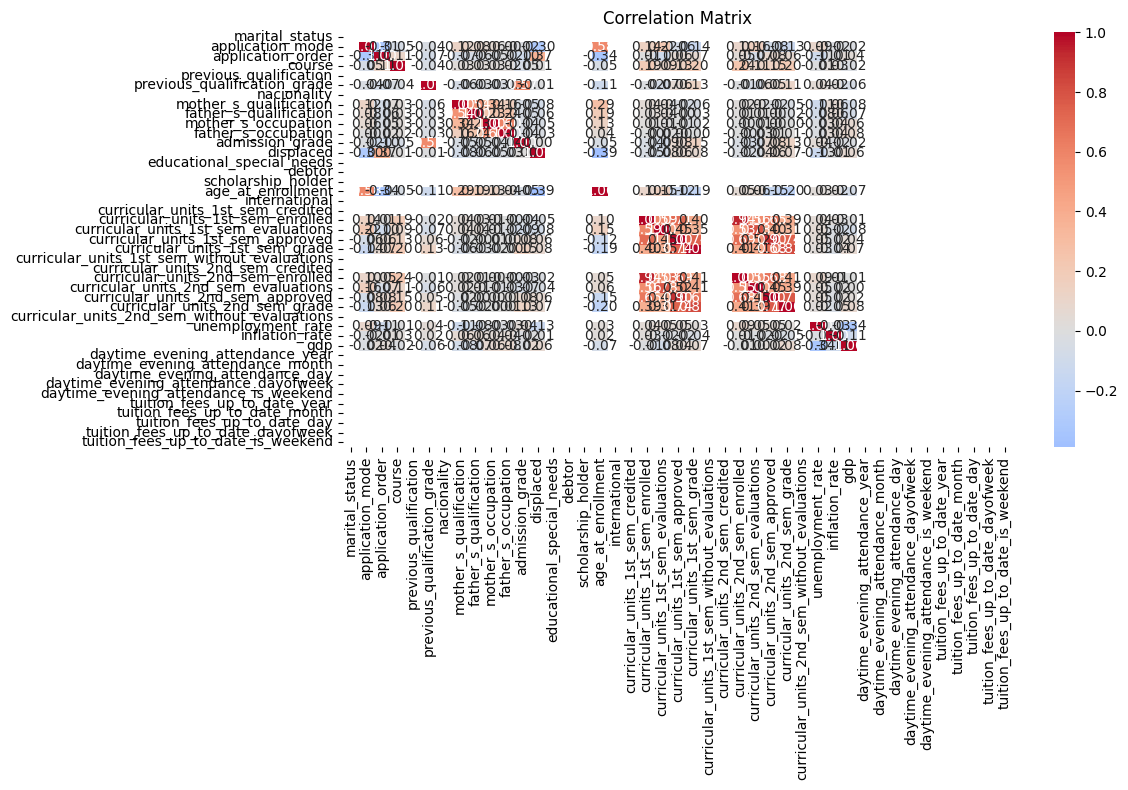

In [76]:
numeric_df = df.select_dtypes(
    include=np.number
)

if numeric_df.shape[1] >= 2:

    correlation_matrix = numeric_df.corr()

    plt.figure(figsize=(12, 8))

    sns.heatmap(
        correlation_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0
    )

    plt.title("Correlation Matrix")
    plt.tight_layout()

    plt.savefig(
        PLOT_DIR / "correlation_matrix.png",
        dpi=300
    )

    plt.show()

In [77]:
TARGET_COLUMN = None

In [78]:
TARGET_COLUMN = "passed"

In [79]:
if TARGET_COLUMN is not None and TARGET_COLUMN in df.columns:

    X = df.drop(
        columns=[TARGET_COLUMN]
    )

    y = df[TARGET_COLUMN]

    print("Feature matrix shape:", X.shape)
    print("Target shape:", y.shape)

else:

    X = df.copy()
    y = None

    print(
        "No target column specified. "
        "All columns will be treated as features."
    )

No target column specified. All columns will be treated as features.


In [80]:
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "string", "bool"]
).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['marital_status', 'application_mode', 'application_order', 'course', 'previous_qualification', 'previous_qualification_grade', 'nacionality', 'mother_s_qualification', 'father_s_qualification', 'mother_s_occupation', 'father_s_occupation', 'admission_grade', 'displaced', 'educational_special_needs', 'debtor', 'scholarship_holder', 'age_at_enrollment', 'international', 'curricular_units_1st_sem_credited', 'curricular_units_1st_sem_enrolled', 'curricular_units_1st_sem_evaluations', 'curricular_units_1st_sem_approved', 'curricular_units_1st_sem_grade', 'curricular_units_1st_sem_without_evaluations', 'curricular_units_2nd_sem_credited', 'curricular_units_2nd_sem_enrolled', 'curricular_units_2nd_sem_evaluations', 'curricular_units_2nd_sem_approved', 'curricular_units_2nd_sem_grade', 'curricular_units_2nd_sem_without_evaluations', 'unemployment_rate', 'inflation_rate', 'gdp', 'daytime_evening_attendance_year', 'daytime_evening_attendance_month', 'daytime_evening_attendance

In [81]:
# Numeric preprocessing
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [82]:
try:

    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )

except TypeError:

    # For older scikit-learn versions
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            one_hot_encoder
        )
    ]
)

In [83]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)

In [84]:
X_processed = preprocessor.fit_transform(X)

print(
    "Processed feature matrix shape:",
    X_processed.shape
)

Processed feature matrix shape: (4424, 48)


In [85]:
feature_names = (
    preprocessor
    .get_feature_names_out()
)

print("Number of transformed features:")
print(len(feature_names))

print("\nFirst 20 features:")
print(feature_names[:20])

Number of transformed features:
48

First 20 features:
['numeric__marital_status' 'numeric__application_mode'
 'numeric__application_order' 'numeric__course'
 'numeric__previous_qualification' 'numeric__previous_qualification_grade'
 'numeric__nacionality' 'numeric__mother_s_qualification'
 'numeric__father_s_qualification' 'numeric__mother_s_occupation'
 'numeric__father_s_occupation' 'numeric__admission_grade'
 'numeric__displaced' 'numeric__educational_special_needs'
 'numeric__debtor' 'numeric__scholarship_holder'
 'numeric__age_at_enrollment' 'numeric__international'
 'numeric__curricular_units_1st_sem_credited'
 'numeric__curricular_units_1st_sem_enrolled']


In [86]:
X_processed_df = pd.DataFrame(
    X_processed,
    columns=feature_names,
    index=X.index
)

display(X_processed_df.head())

,numeric__marital_status,numeric__application_mode,numeric__application_order,numeric__course,numeric__previous_qualification,numeric__previous_qualification_grade,numeric__nacionality,numeric__mother_s_qualification,numeric__father_s_qualification,numeric__mother_s_occupation,...,numeric__tuition_fees_up_to_date_year,numeric__tuition_fees_up_to_date_month,numeric__tuition_fees_up_to_date_day,numeric__tuition_fees_up_to_date_dayofweek,numeric__tuition_fees_up_to_date_is_weekend,categorical__gender_0,categorical__gender_1,categorical__target_Dropout,categorical__target_Enrolled,categorical__target_Graduate
0,0.0,-0.095470,2.102099,-2.191159,0.0,-0.834072,0.0,-0.036018,-0.669778,-0.359174,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,0.0,-0.209869,-0.619176,-0.099999,0.0,2.183947,0.0,-1.189759,-1.256427,-0.930443,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,0.0,-1.010660,2.102099,-0.539489,0.0,-0.834072,0.0,1.117723,0.959802,0.783364,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,0.0,-0.095470,0.469334,1.139649,0.0,-0.834072,0.0,1.181819,0.959802,-0.359174,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.0,1.162916,-0.619176,-2.191159,0.0,-2.382792,0.0,1.117723,1.024985,0.783364,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [87]:
if y is not None:

    processed_dataset = X_processed_df.copy()

    processed_dataset[TARGET_COLUMN] = (
        y.values
    )

else:

    processed_dataset = X_processed_df.copy()

display(processed_dataset.head())

,numeric__marital_status,numeric__application_mode,numeric__application_order,numeric__course,numeric__previous_qualification,numeric__previous_qualification_grade,numeric__nacionality,numeric__mother_s_qualification,numeric__father_s_qualification,numeric__mother_s_occupation,...,numeric__tuition_fees_up_to_date_year,numeric__tuition_fees_up_to_date_month,numeric__tuition_fees_up_to_date_day,numeric__tuition_fees_up_to_date_dayofweek,numeric__tuition_fees_up_to_date_is_weekend,categorical__gender_0,categorical__gender_1,categorical__target_Dropout,categorical__target_Enrolled,categorical__target_Graduate
0,0.0,-0.095470,2.102099,-2.191159,0.0,-0.834072,0.0,-0.036018,-0.669778,-0.359174,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,0.0,-0.209869,-0.619176,-0.099999,0.0,2.183947,0.0,-1.189759,-1.256427,-0.930443,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,0.0,-1.010660,2.102099,-0.539489,0.0,-0.834072,0.0,1.117723,0.959802,0.783364,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,0.0,-0.095470,0.469334,1.139649,0.0,-0.834072,0.0,1.181819,0.959802,-0.359174,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.0,1.162916,-0.619176,-2.191159,0.0,-2.382792,0.0,1.117723,1.024985,0.783364,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [88]:
CLEANED_FILE = OUTPUT_DIR / "cleaned_dataset.csv"

df.to_csv(
    CLEANED_FILE,
    index=False
)

print(
    f"Cleaned CSV saved successfully at:\n{CLEANED_FILE}"
)

Cleaned CSV saved successfully at:
week2_outputs\cleaned_dataset.csv


In [89]:
PROCESSED_FILE = OUTPUT_DIR / "processed_dataset.csv"

processed_dataset.to_csv(
    PROCESSED_FILE,
    index=False
)

print(
    f"Processed dataset saved at:\n{PROCESSED_FILE}"
)

Processed dataset saved at:
week2_outputs\processed_dataset.csv


In [90]:
final_report = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Missing_Values": df.isnull().sum().values,
    "Unique_Values": df.nunique().values
})

final_report["Missing_Percentage"] = (
    final_report["Missing_Values"]
    / len(df) * 100
)

display(final_report)

,Column,Data_Type,Missing_Values,Unique_Values,Missing_Percentage
0,marital_status,int64,0,1,0.0
1,application_mode,int64,0,18,0.0
2,application_order,float64,0,5,0.0
3,course,float64,0,15,0.0
4,daytime_evening_attendance,datetime64[ns],0,2,0.0
5,previous_qualification,int64,0,1,0.0
6,previous_qualification_grade,float64,0,76,0.0
7,nacionality,int64,0,1,0.0
8,mother_s_qualification,int64,0,29,0.0
9,father_s_qualification,int64,0,34,0.0


In [91]:
final_report.to_csv(
    REPORT_DIR / "final_data_quality_report.csv",
    index=False
)